# Chapter 3 — all figures and tables

*Statistical Models for Extreme Events* — R. Kardkasem, The University of Queensland

Reproduces **every figure and every table in Chapter 3** and displays them inline,
then checks the regenerated numbers against the values printed in the thesis.

## 1. Setup

In [1]:
import os, sys, subprocess
from pathlib import Path

ROOT = Path.cwd()
SRC  = ROOT / "src"
os.environ.setdefault("DATA_DIR", str(ROOT / "data"))
os.environ.setdefault("OUT_DIR",  str(ROOT / "outputs"))
sys.path.insert(0, str(SRC))

from IPython.display import Image, Markdown, display
import pandas as pd
pd.set_option("display.width", 140, "display.max_columns", 50)

OUT = Path(os.environ["OUT_DIR"])
print("data:", os.environ["DATA_DIR"])
print("out :", OUT)

data: /tmp/nbtest2/data
out : /tmp/nbtest2/outputs


## 2. Run the pipeline

Fits the GEV model ladder, produces every figure and table, and writes the
verification report. Skip this cell if `outputs/` is already populated.

## 3. Tables

Each is generated from the fitted model and written as a drop-in `.tex` plus a
`.csv` of the same numbers. The `.csv` is shown here.

In [2]:
TABLES = [
    ("Table 3.1  Model specification",            None),
    ("Table 3.2  Descriptive statistics",         "tab_mmk_descriptive.csv"),
    ("Table 3.3  Model comparison, k = 1,2,3",    "tab_model_comparison_k123.csv"),
    ("Table 3.4  Model 4 parameter estimates",    "tab_model4_compact.csv"),
    ("Table 3.5  Exceedance probabilities",       "tab_multiday_exceedance.csv"),
    ("Extremal index summary (under Fig 3.2)",    "tab_theta_summary.csv"),
]
for title, fname in TABLES:
    display(Markdown(f"### {title}"))
    if fname is None:
        display(Markdown("*Definitional; see `outputs/chapter3_tables/tab_gev_models.tex`.*"))
        continue
    p = OUT / "chapter3_tables" / fname
    display(pd.read_csv(p).round(4) if p.exists() else Markdown(f"*missing: {p}*"))

### Table 3.1  Model specification

*Definitional; see `outputs/chapter3_tables/tab_gev_models.tex`.*

### Table 3.2  Descriptive statistics

,k,n,mean,sd,min,q1,q2,q3,max
0,1,18240,67.7667,46.8415,6.4,40.0,55.4,79.2,653.0
1,2,18240,28.4607,25.3466,0.0,14.4,21.5,33.2,380.0
2,3,18240,13.3312,15.4484,0.0,5.2,9.2,15.8,265.0
3,4,18240,6.8135,10.0167,0.0,1.6,4.0,8.2,195.8
4,5,18240,3.7004,7.0259,0.0,0.2,1.6,4.2,185.0
5,6,18240,2.1604,5.4397,0.0,0.0,0.6,2.2,185.0
6,7,18240,1.3225,4.0528,0.0,0.0,0.0,1.2,158.0
7,8,18240,0.8133,2.8876,0.0,0.0,0.0,0.6,142.0
8,9,18240,0.5322,2.2967,0.0,0.0,0.0,0.2,142.0
9,10,18240,0.3534,1.8655,0.0,0.0,0.0,0.0,135.0


### Table 3.3  Model comparison, k = 1,2,3

...

,k,covariate,mu_estimate,mu_se,logsigma_estimate,logsigma_se,xi_estimate,xi_se
0,1,Intercept,50.9097,0.1801,2.9580,0.0065,0.1442,0.0057
1,1,SOI,1.4500,0.1384,0.0016,0.0063,0.1442,0.0057
2,1,Latitude,10.4203,0.1934,0.2764,0.0067,0.1442,0.0057
3,1,Longitude,5.6643,0.1610,0.0584,0.0067,0.1442,0.0057
4,1,$\log(\mathrm{cdist})$,-8.9692,0.2482,-0.2704,0.0076,0.1442,0.0057
5,2,Intercept,19.5491,0.0904,2.2494,0.0065,0.1604,0.0059
6,2,SOI,0.8046,0.0651,0.0108,0.0064,0.1604,0.0059
7,2,Latitude,3.7923,0.0930,0.3078,0.0068,0.1604,0.0059
8,2,Longitude,2.9371,0.0760,0.1048,0.0069,0.1604,0.0059
9,2,$\log(\mathrm{cdist})$,-4.8667,0.1225,-0.2874,0.0079,0.1604,0.0059


### Table 3.5  Exceedance probabilities

,k,city,station_num,threshold_mm,p_2010_la_nina,p_2015_el_nino,change_pp
0,1,Townsville,32040.0,226.2511,0.1,0.1010,0.0988
1,1,Gympie,40390.0,166.8070,0.1,0.0920,-0.8000
2,1,Brisbane,40458.0,227.5393,0.1,0.0947,-0.5283
3,1,Lismore,58171.0,186.3164,0.1,0.0969,-0.3054
4,1,Windsor,67019.0,111.7471,0.1,0.1058,0.5802
5,1,Charlton,78072.0,63.1593,0.1,0.0784,-2.1572
6,2,Townsville,32040.0,110.6243,0.1,0.1004,0.0423
7,2,Gympie,40390.0,83.1018,0.1,0.0885,-1.1468
8,2,Brisbane,40458.0,121.2079,0.1,0.0880,-1.1988
9,2,Lismore,58171.0,96.6230,0.1,0.0899,-1.0055


### Extremal index summary (under Fig 3.2)

,statistic,n_stations,mean,sd,min,q1,q2,q3,max
0,theta,454,0.6918,0.1341,0.2366,0.6459,0.7212,0.7744,0.9844
1,inv_theta_empirical,454,1.5341,0.4877,1.0159,1.2913,1.3865,1.5481,4.2259
2,inv_theta_plugin,454,1.4455,0.2801,1.0159,1.2913,1.3865,1.5481,4.2259


## 4. Figures


### Figure 3.1 — Annual maxima against covariates

`annual_max_vs_covariates_combined_3x2.png`

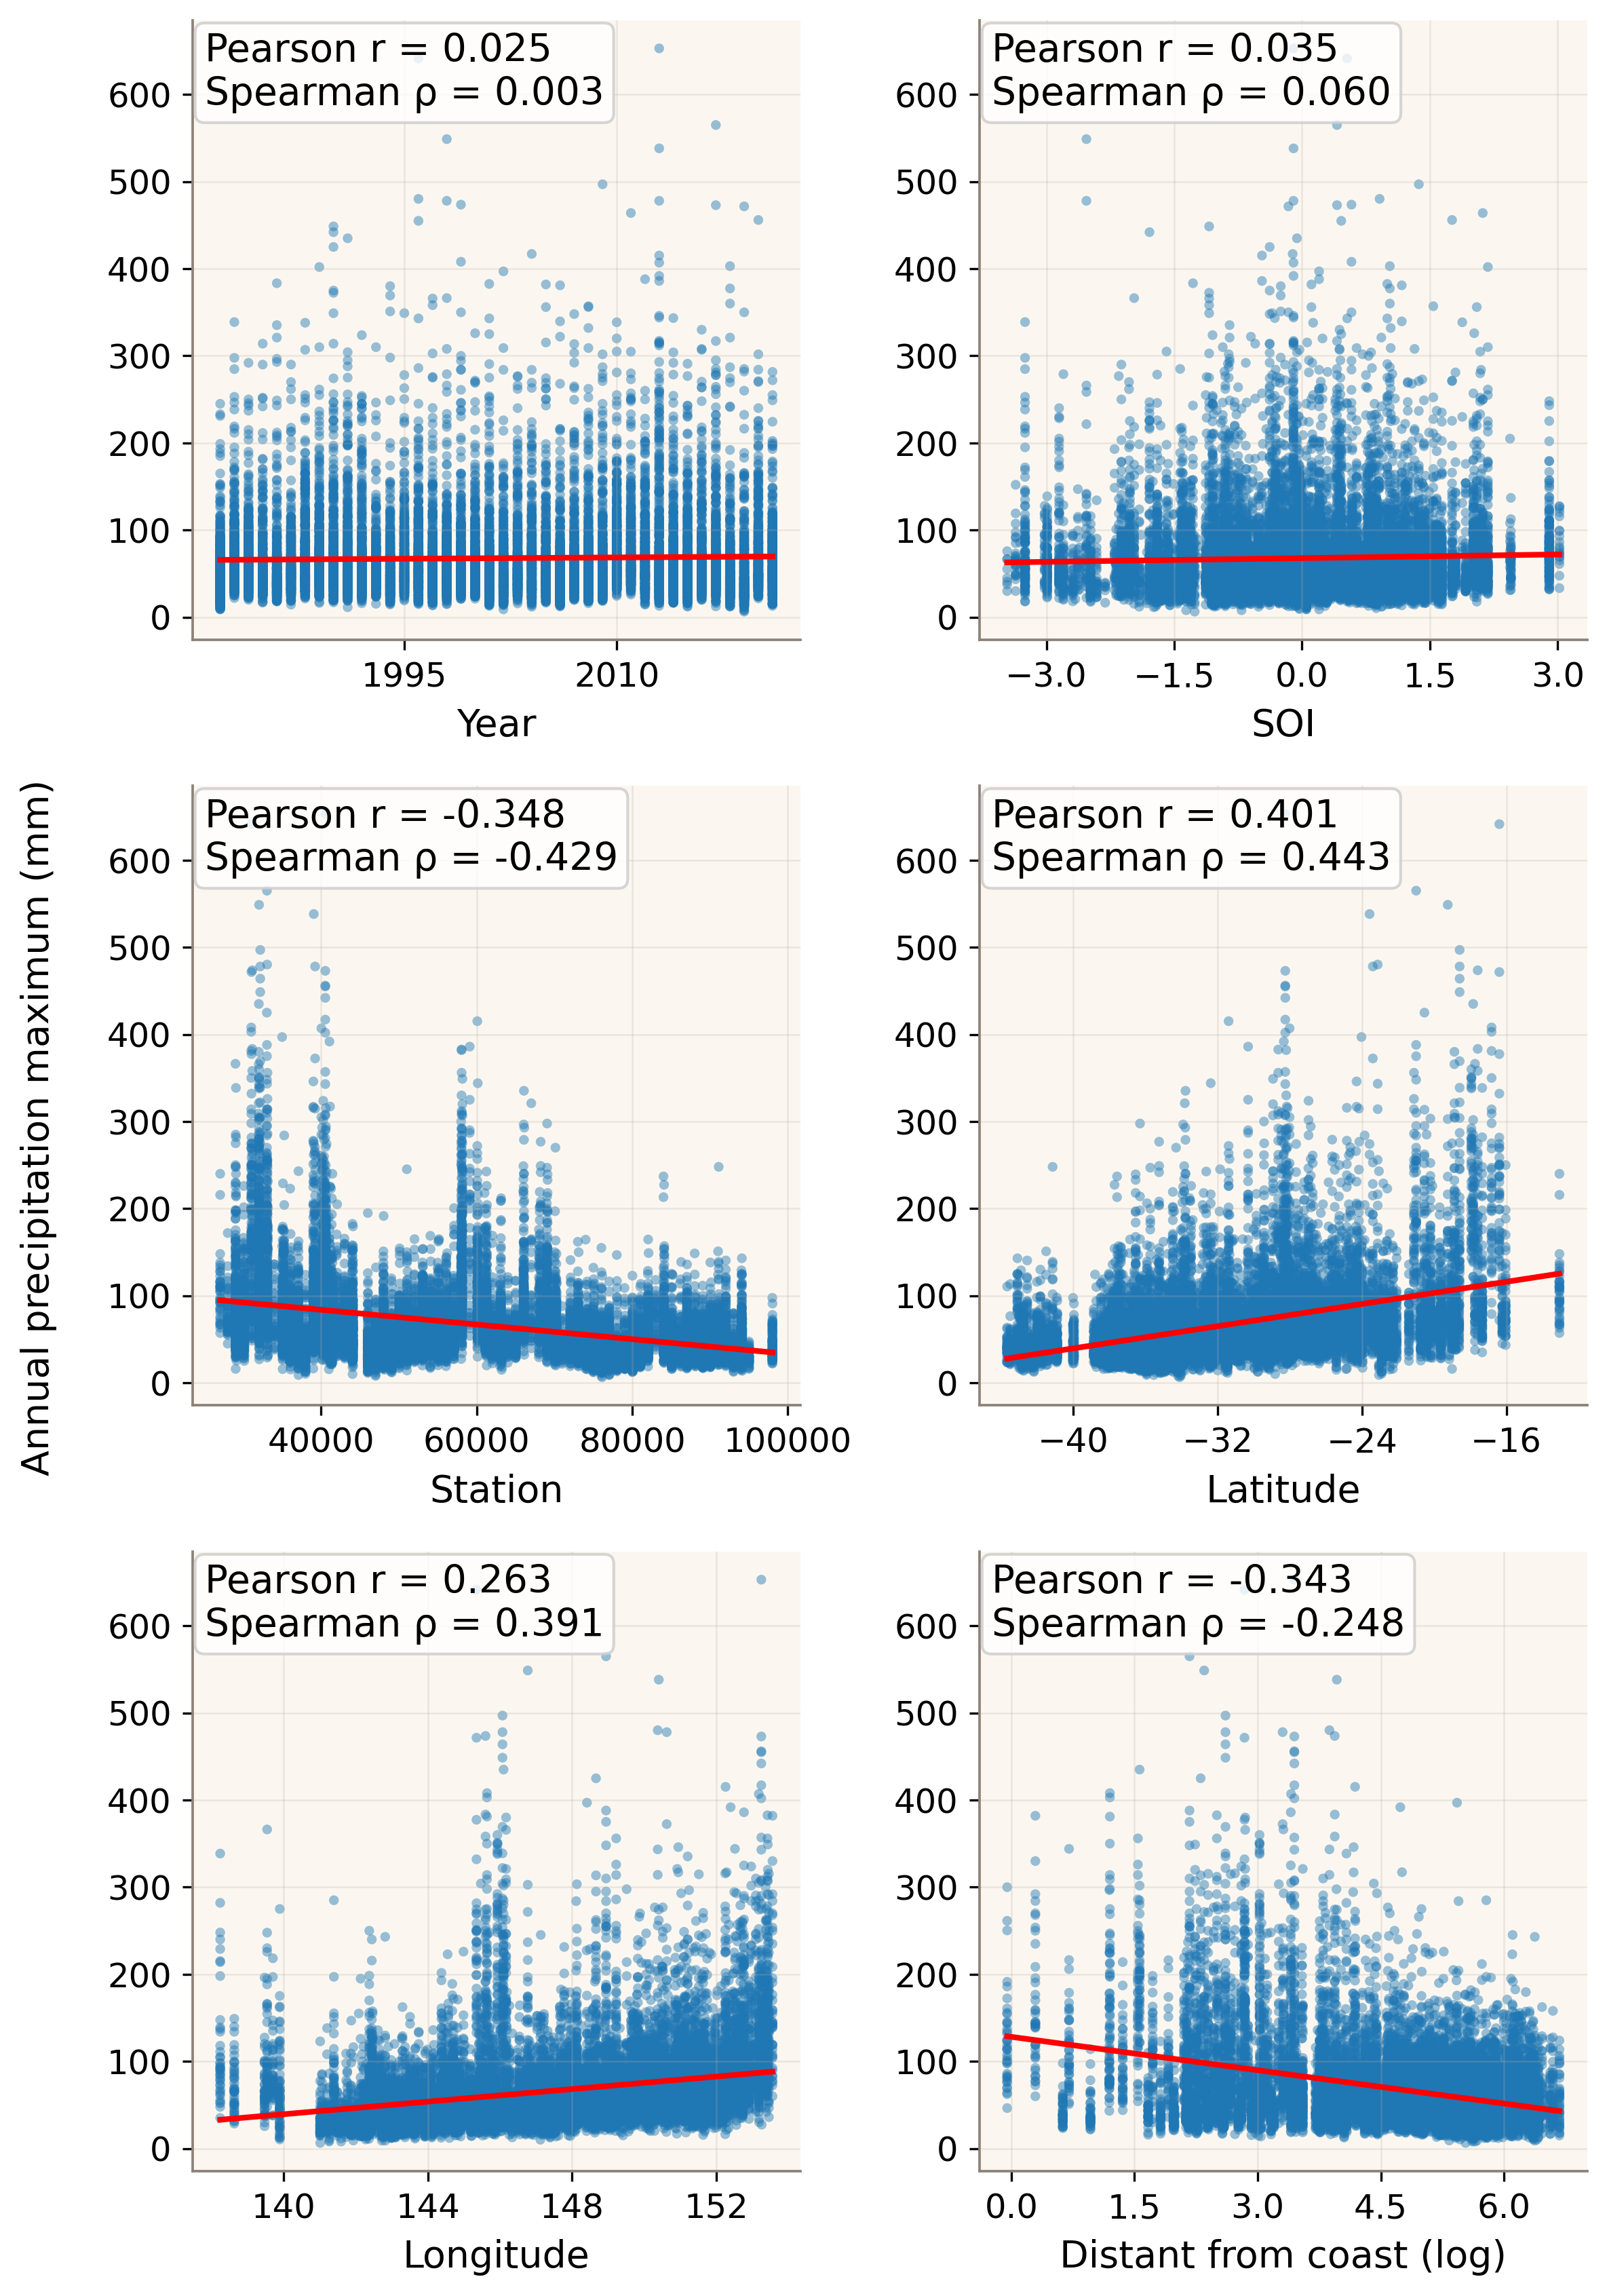

### Figure 3.2 — Extremal index at u = 0.95

`0.95.PNG`

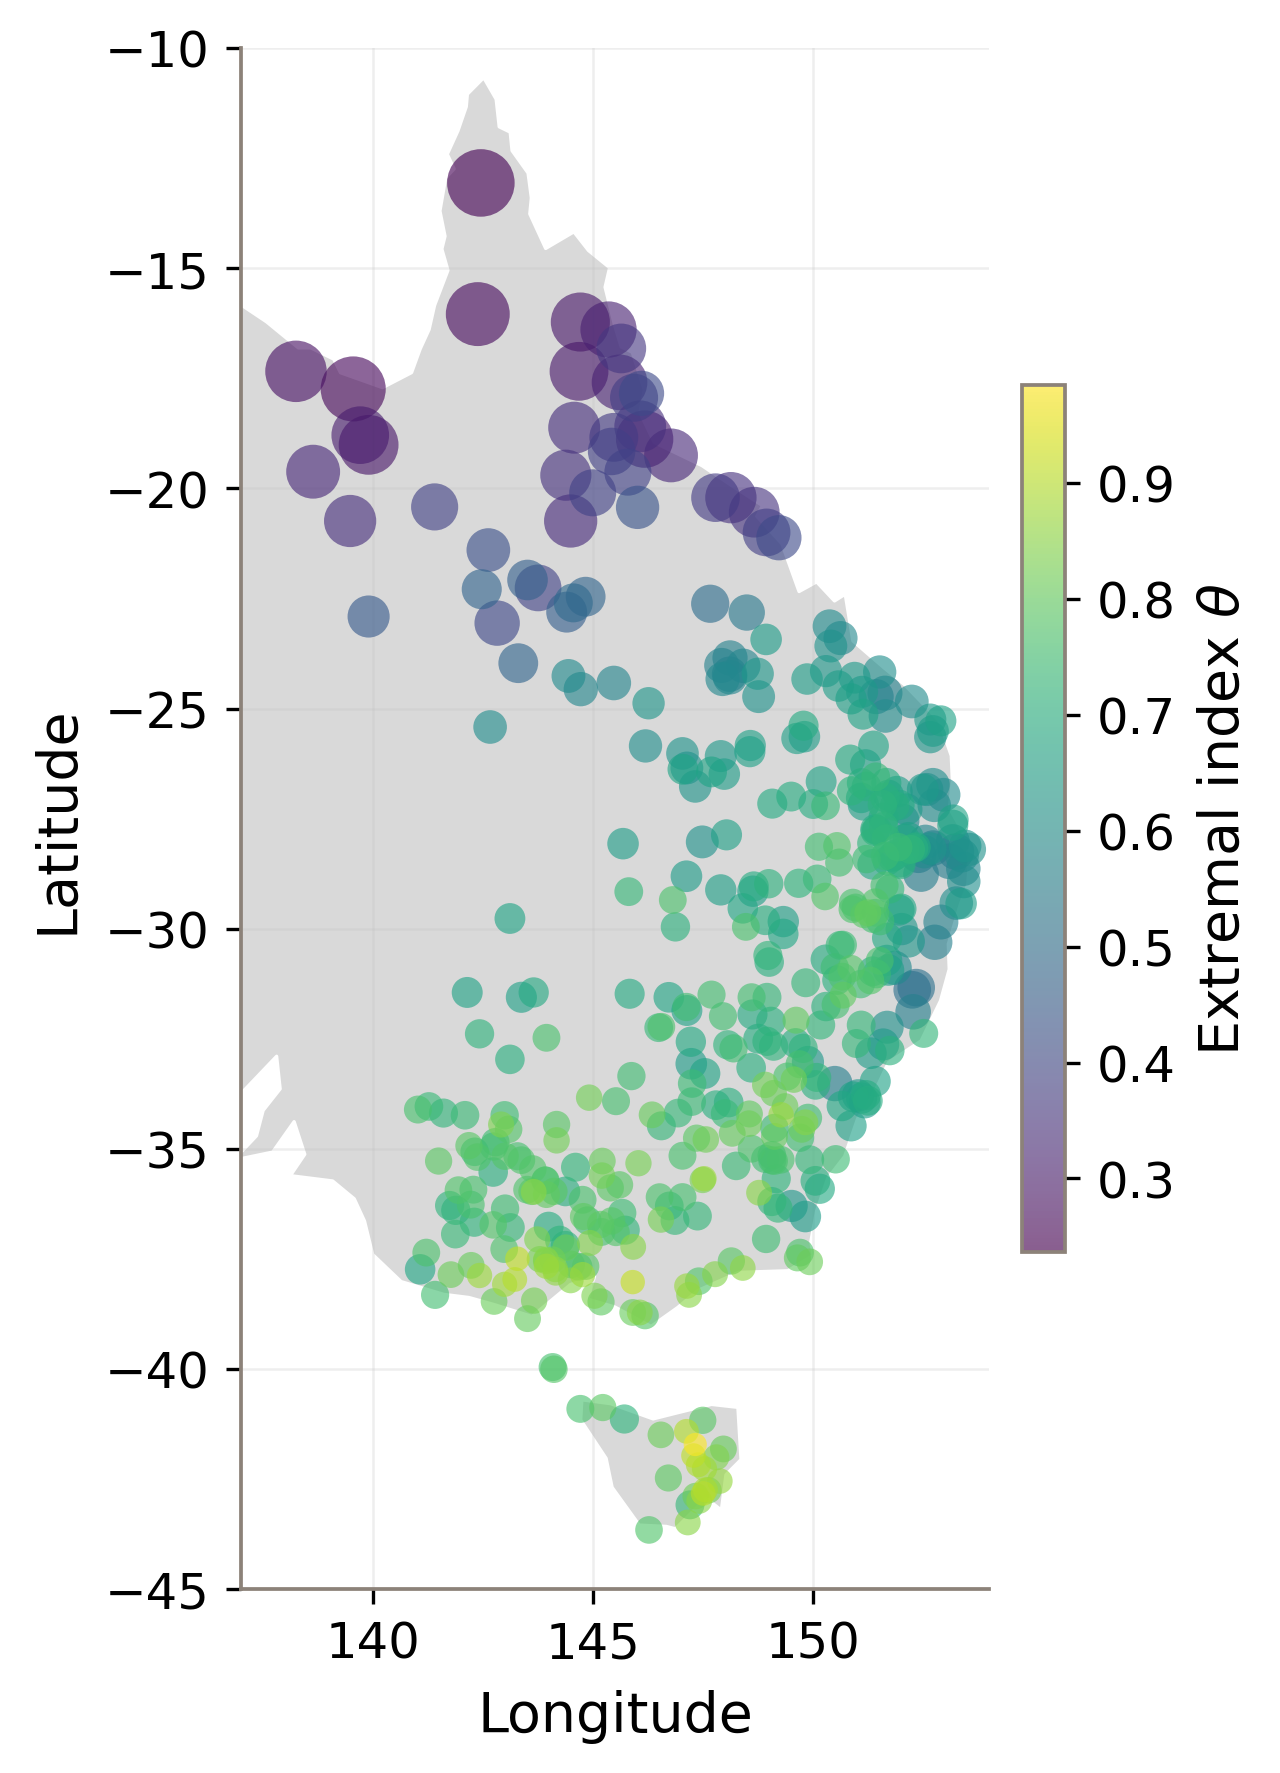

### Figure 3.3 — Shape parameter over block length

`shape_parameter_model4_over_k.png`

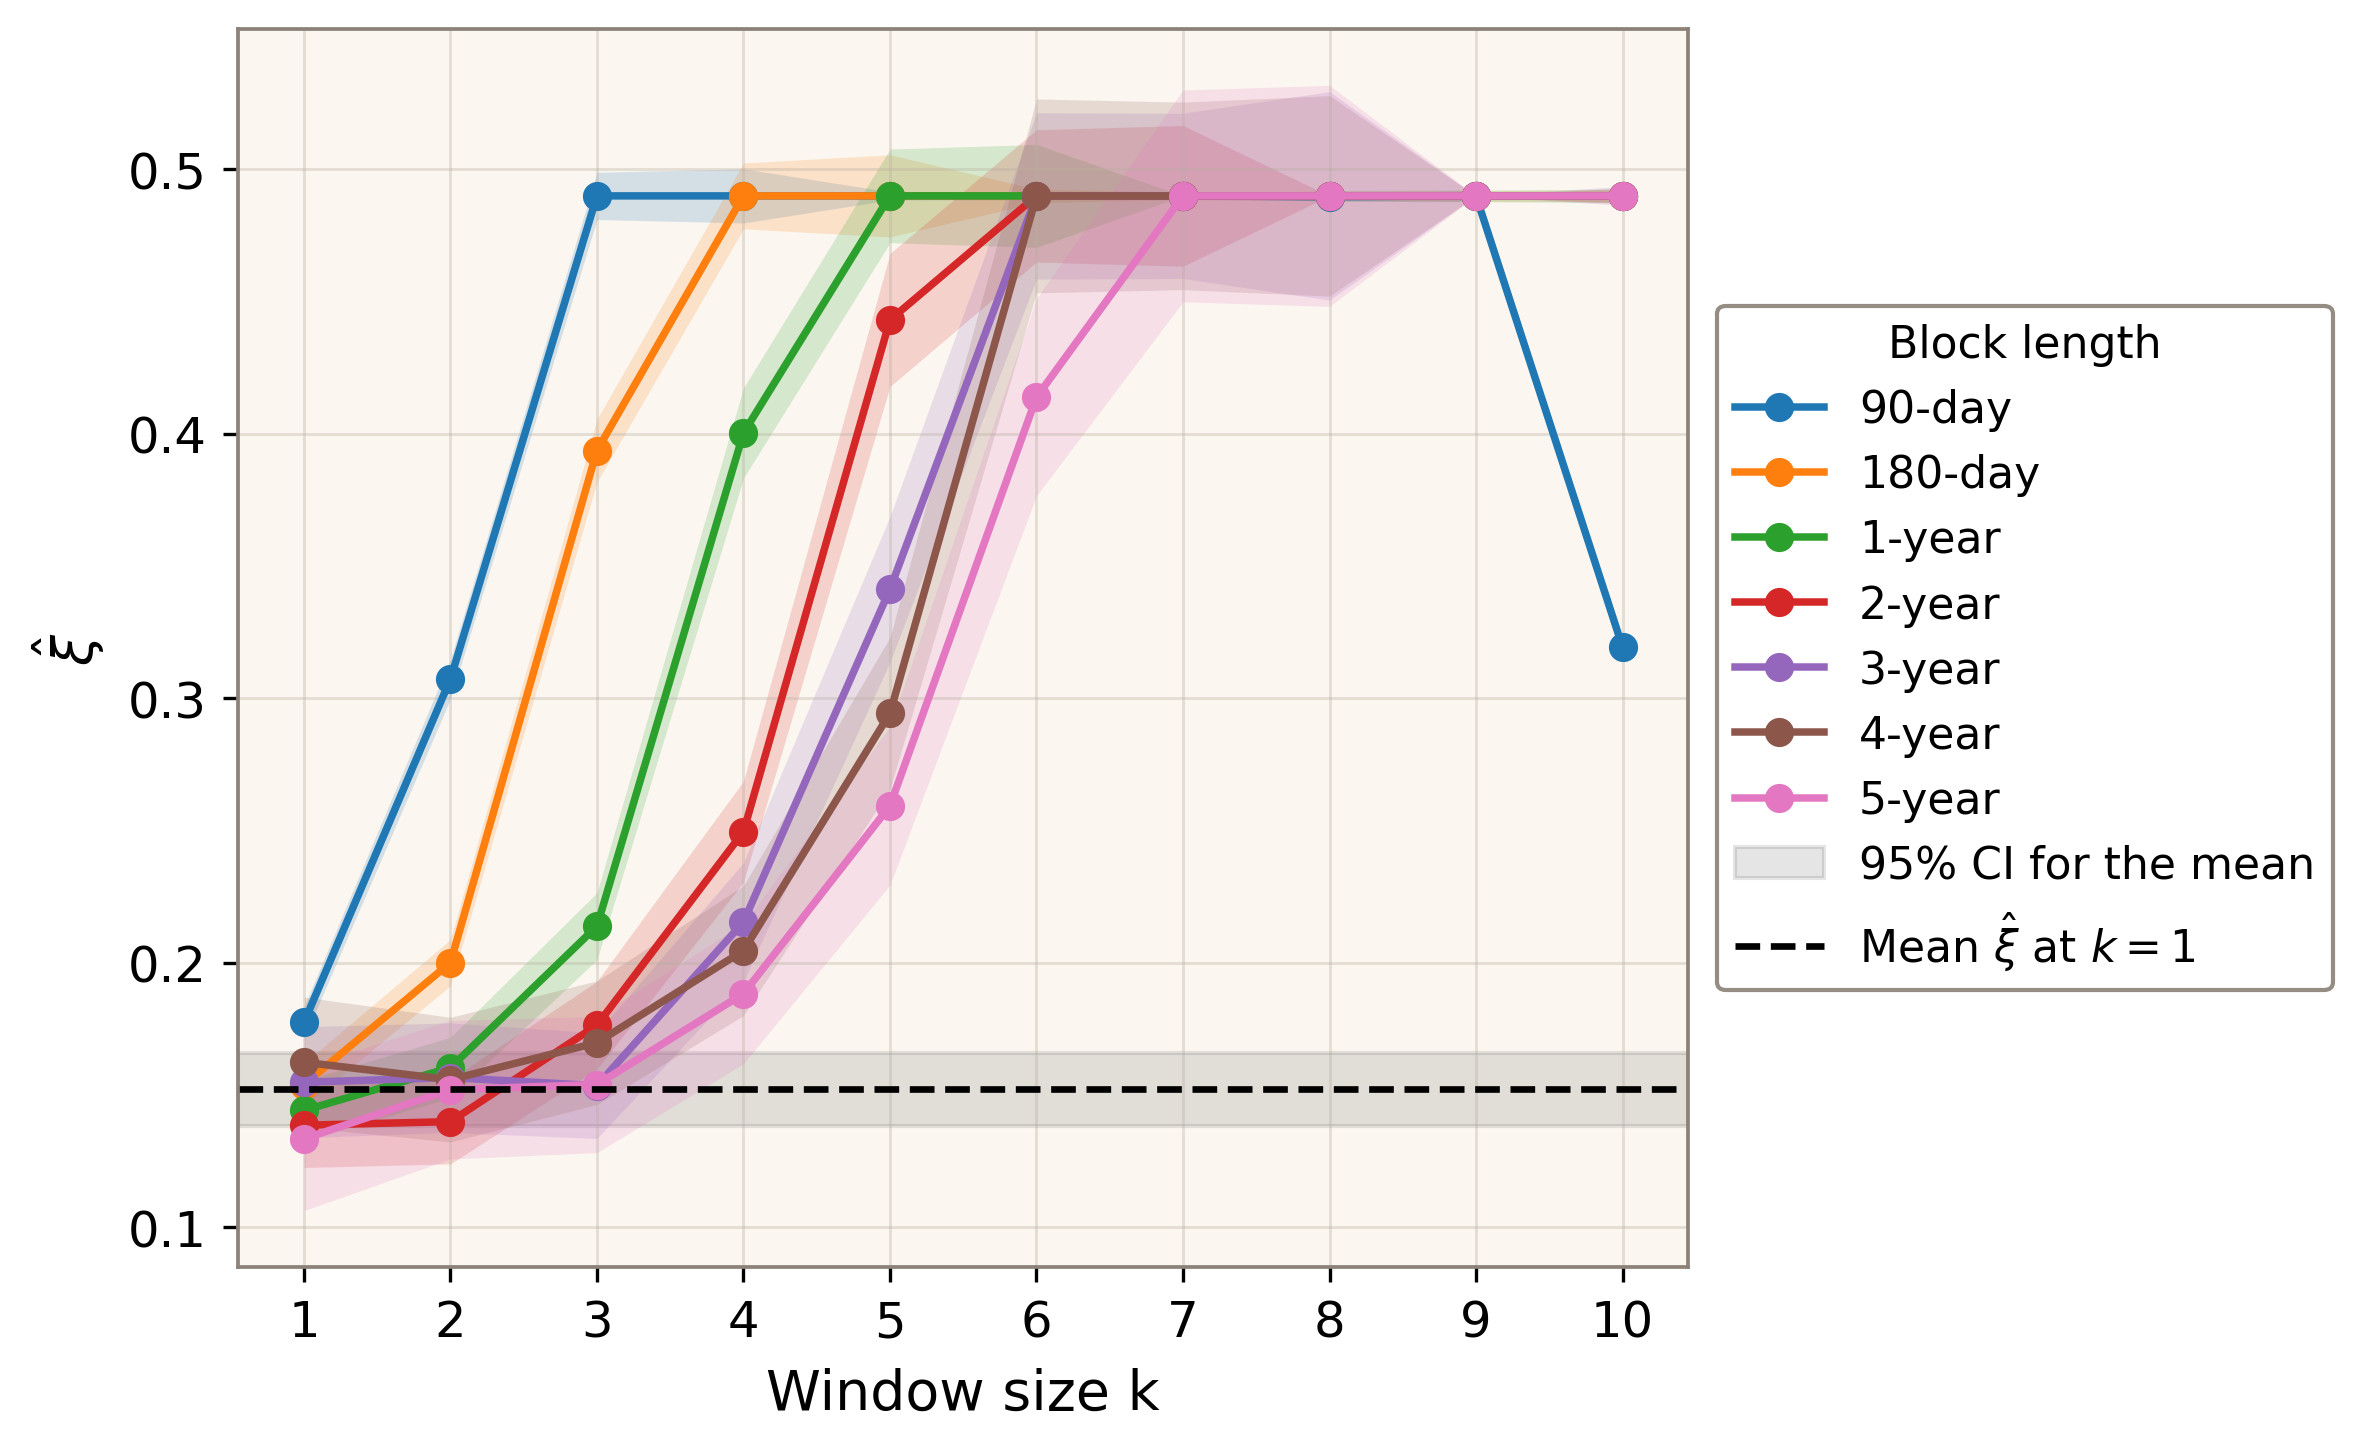

### Figure 3.4 — Annual maxima for k = 1..10

`boxplot_mm_k.png`

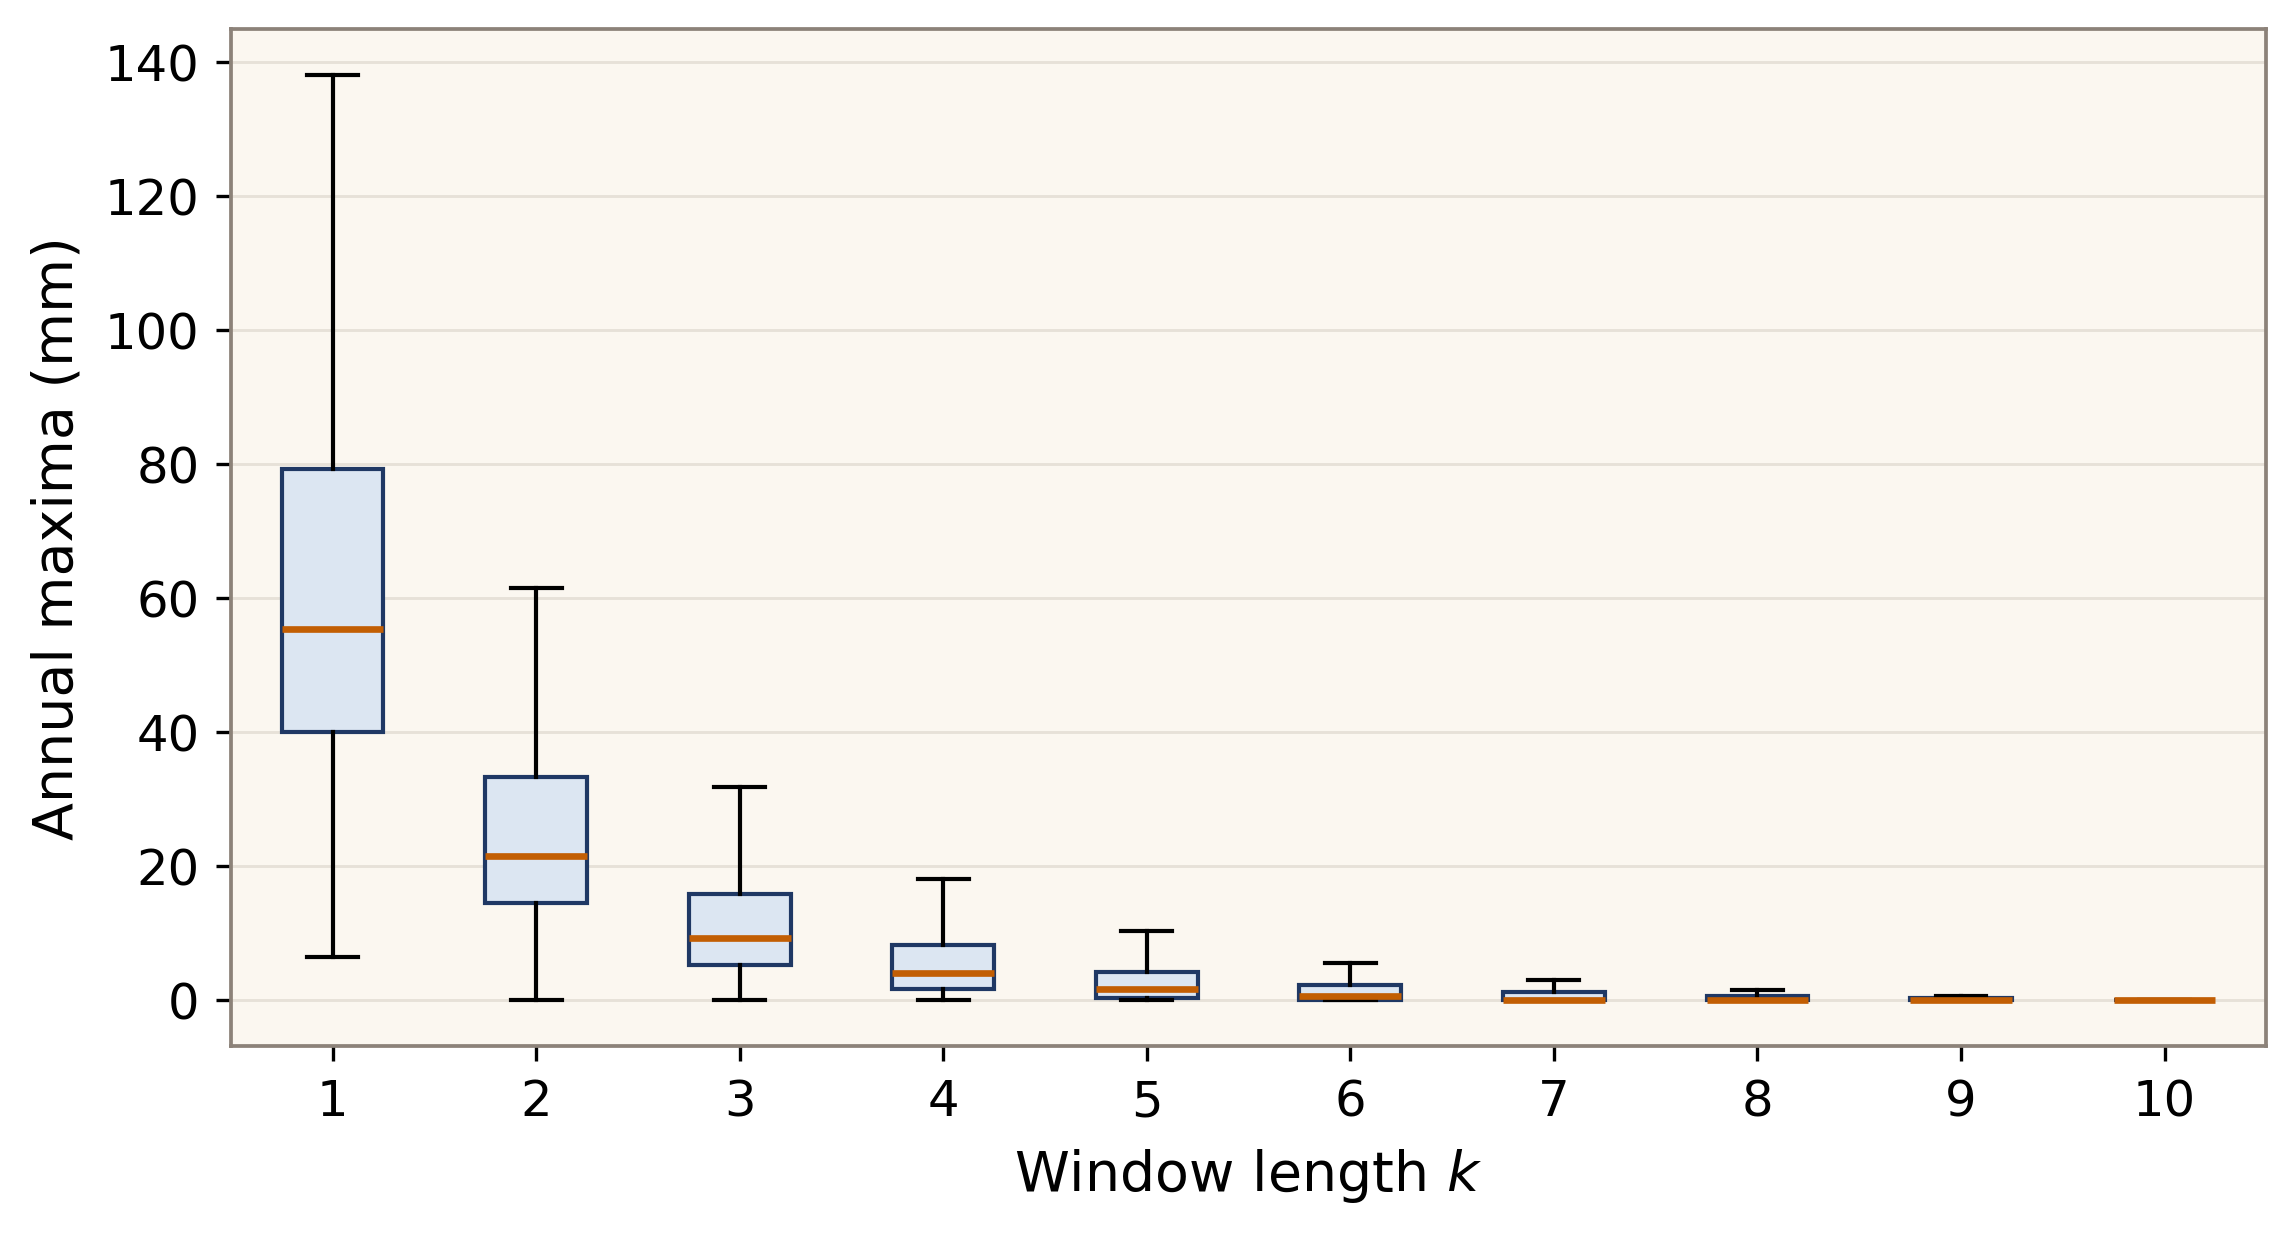

### Figure 3.5 — GEV parameters over k

`model4_mu_sigma_shape_over_k_3x3.png`

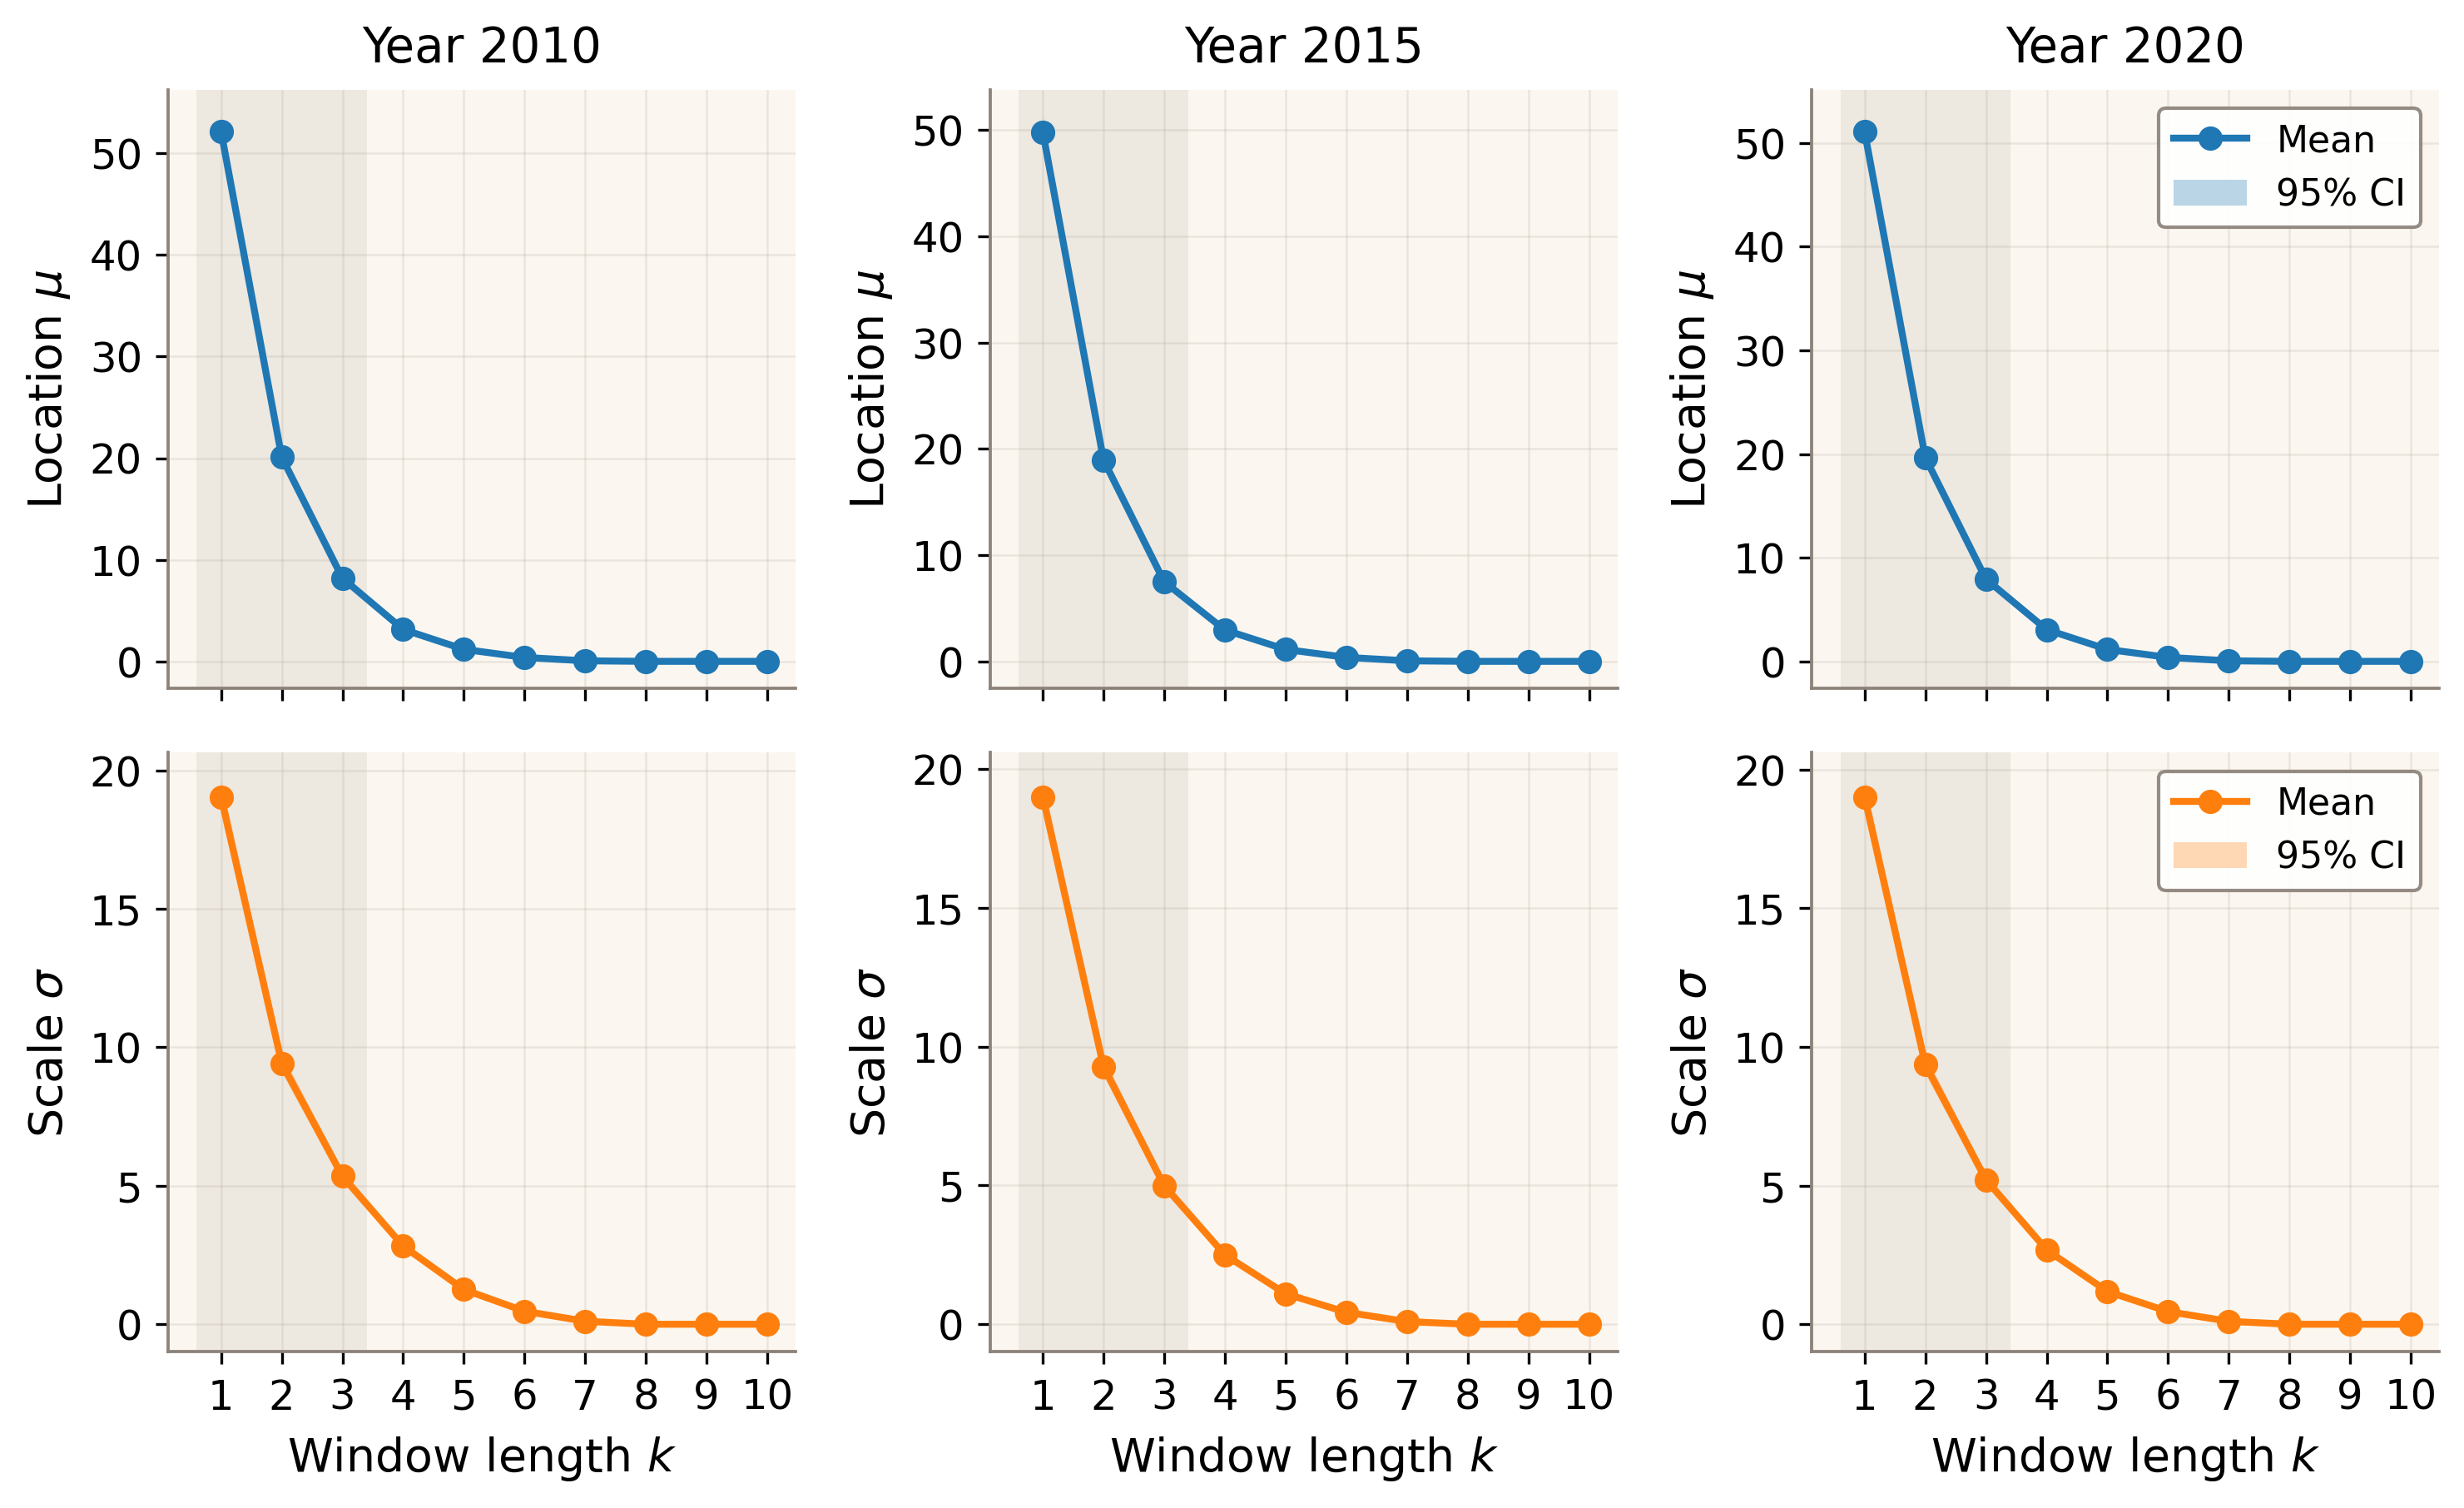

### Figure 3.6 — Selected stations

`selected_stations_map_fixed.png`

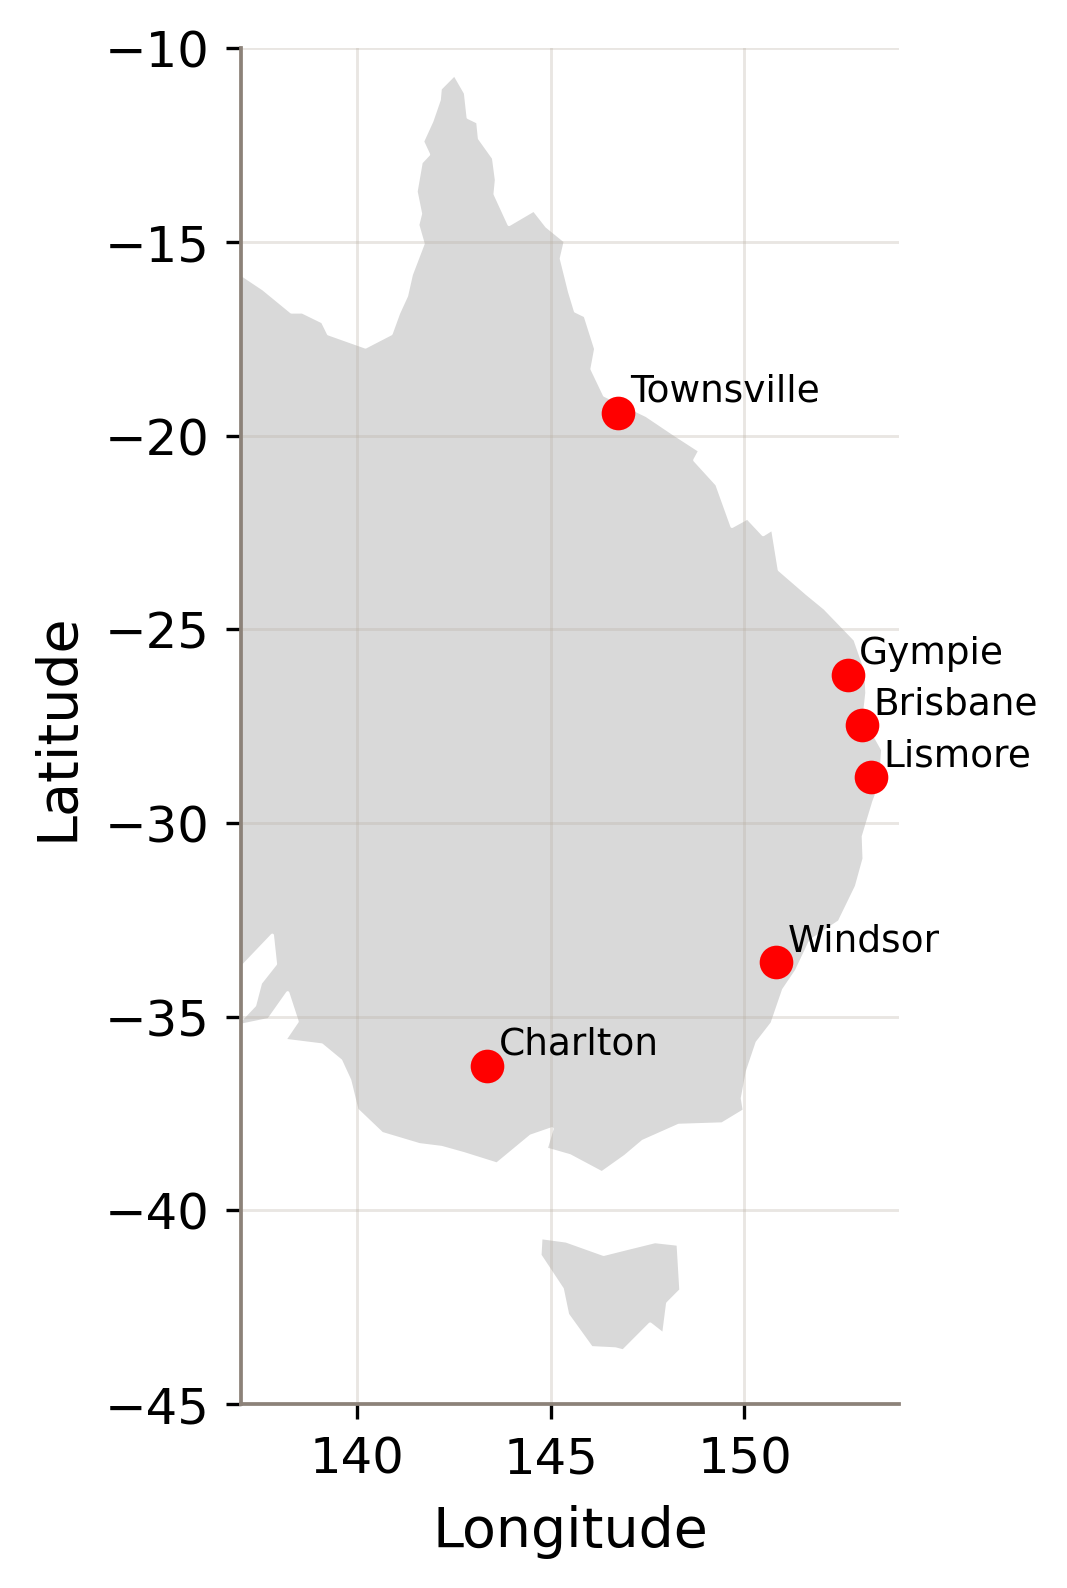

### Figure 3.7 — Annual moving minima, selected stations

`boxplot_k1234_shared_ylim.png`

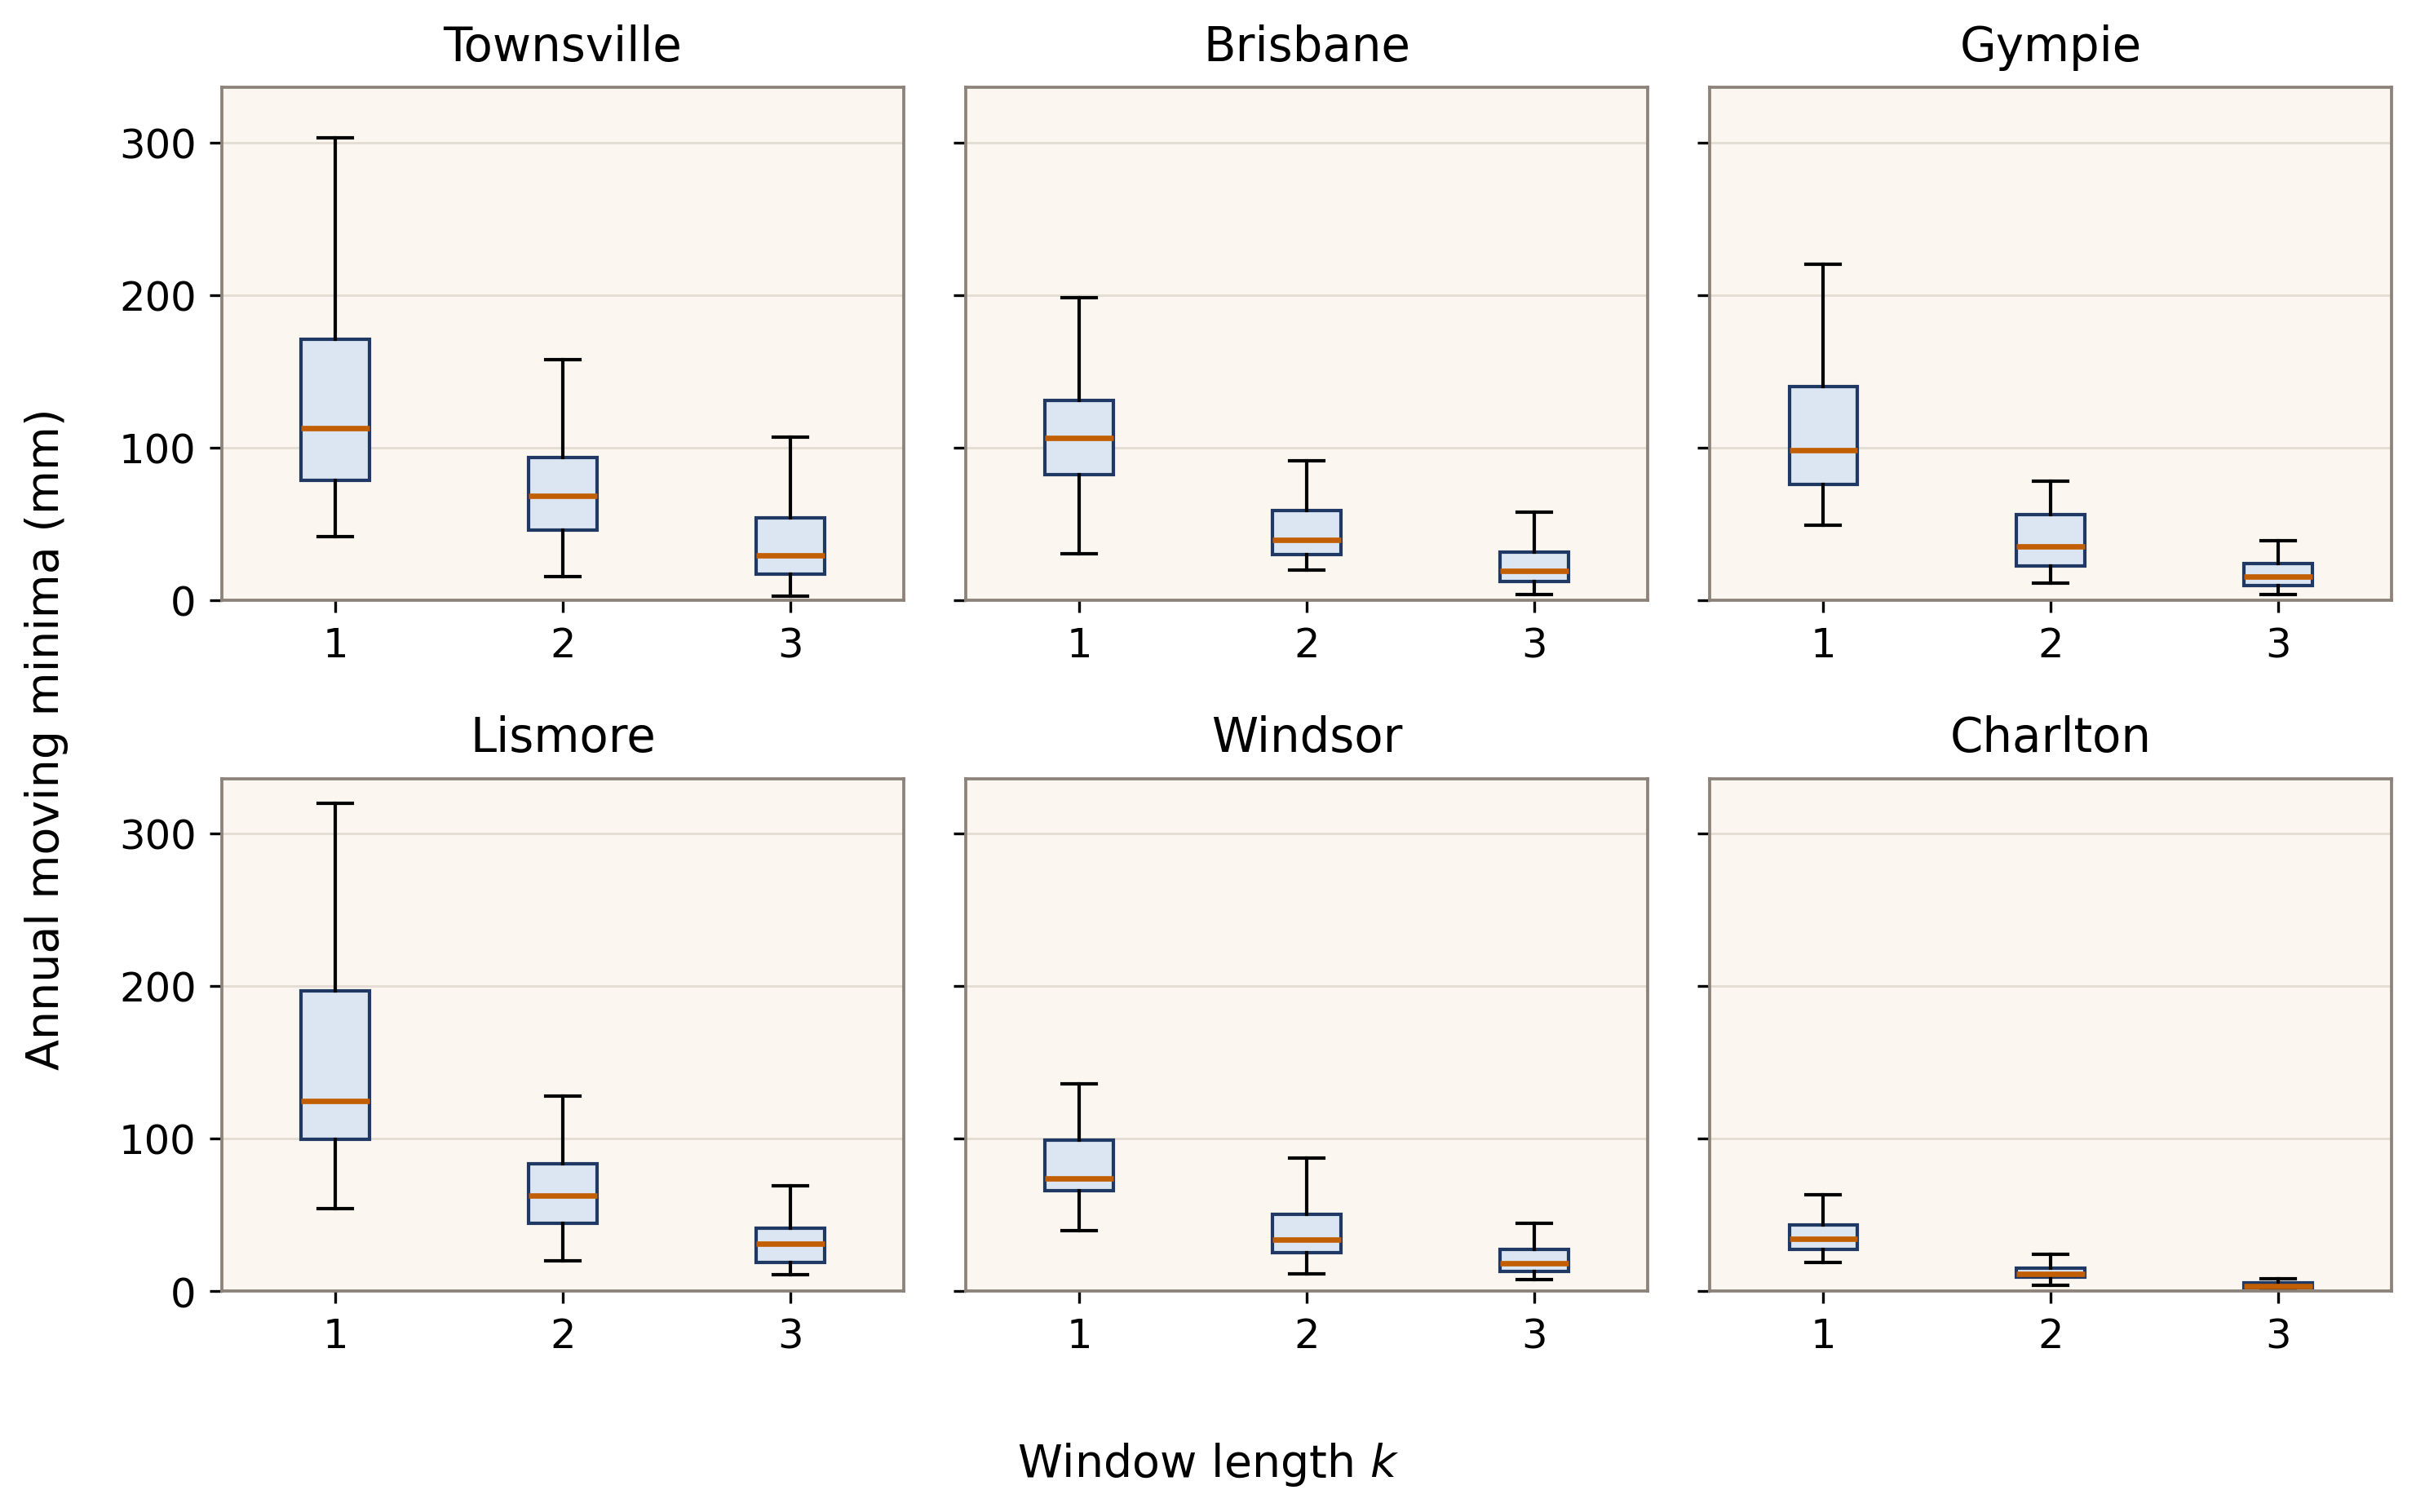

### Figure 3.8 — Location parameter

`model4_mu_over_k_1_to_3_clean_same_ylim.png`

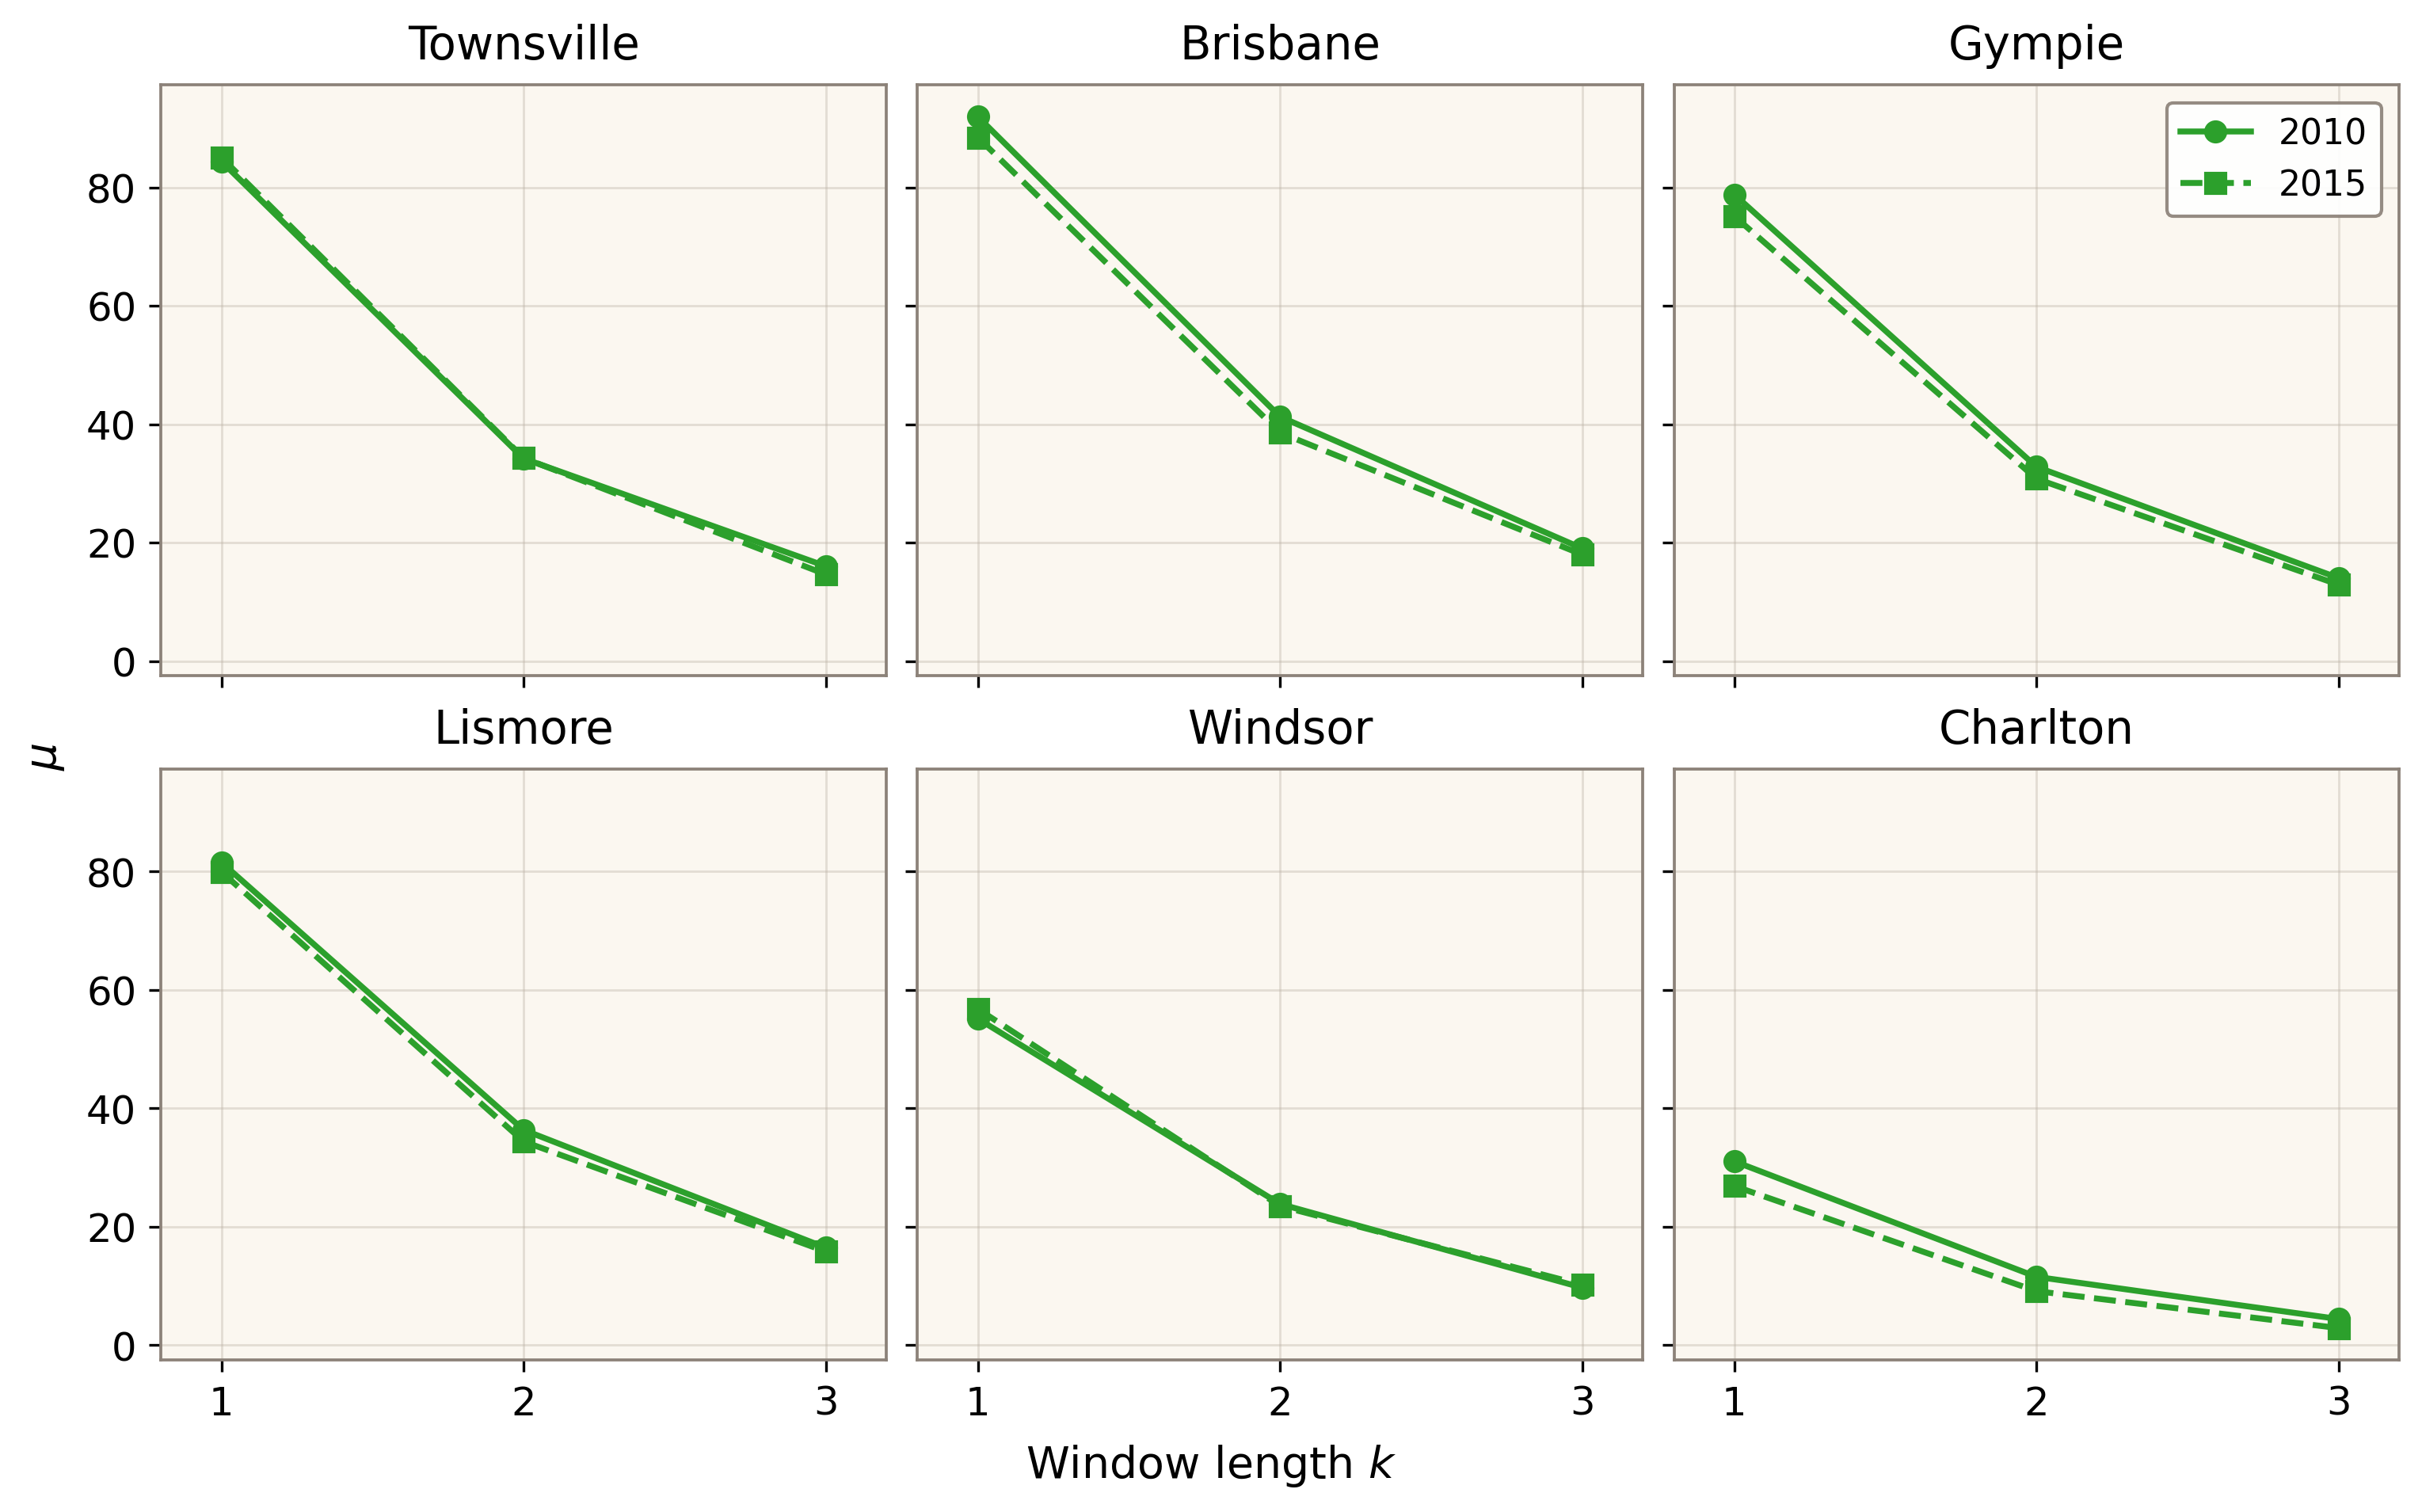

### Figure 3.9 — Scale parameter

`model4_sigma_over_k_1_to_3_clean_same_ylim.png`

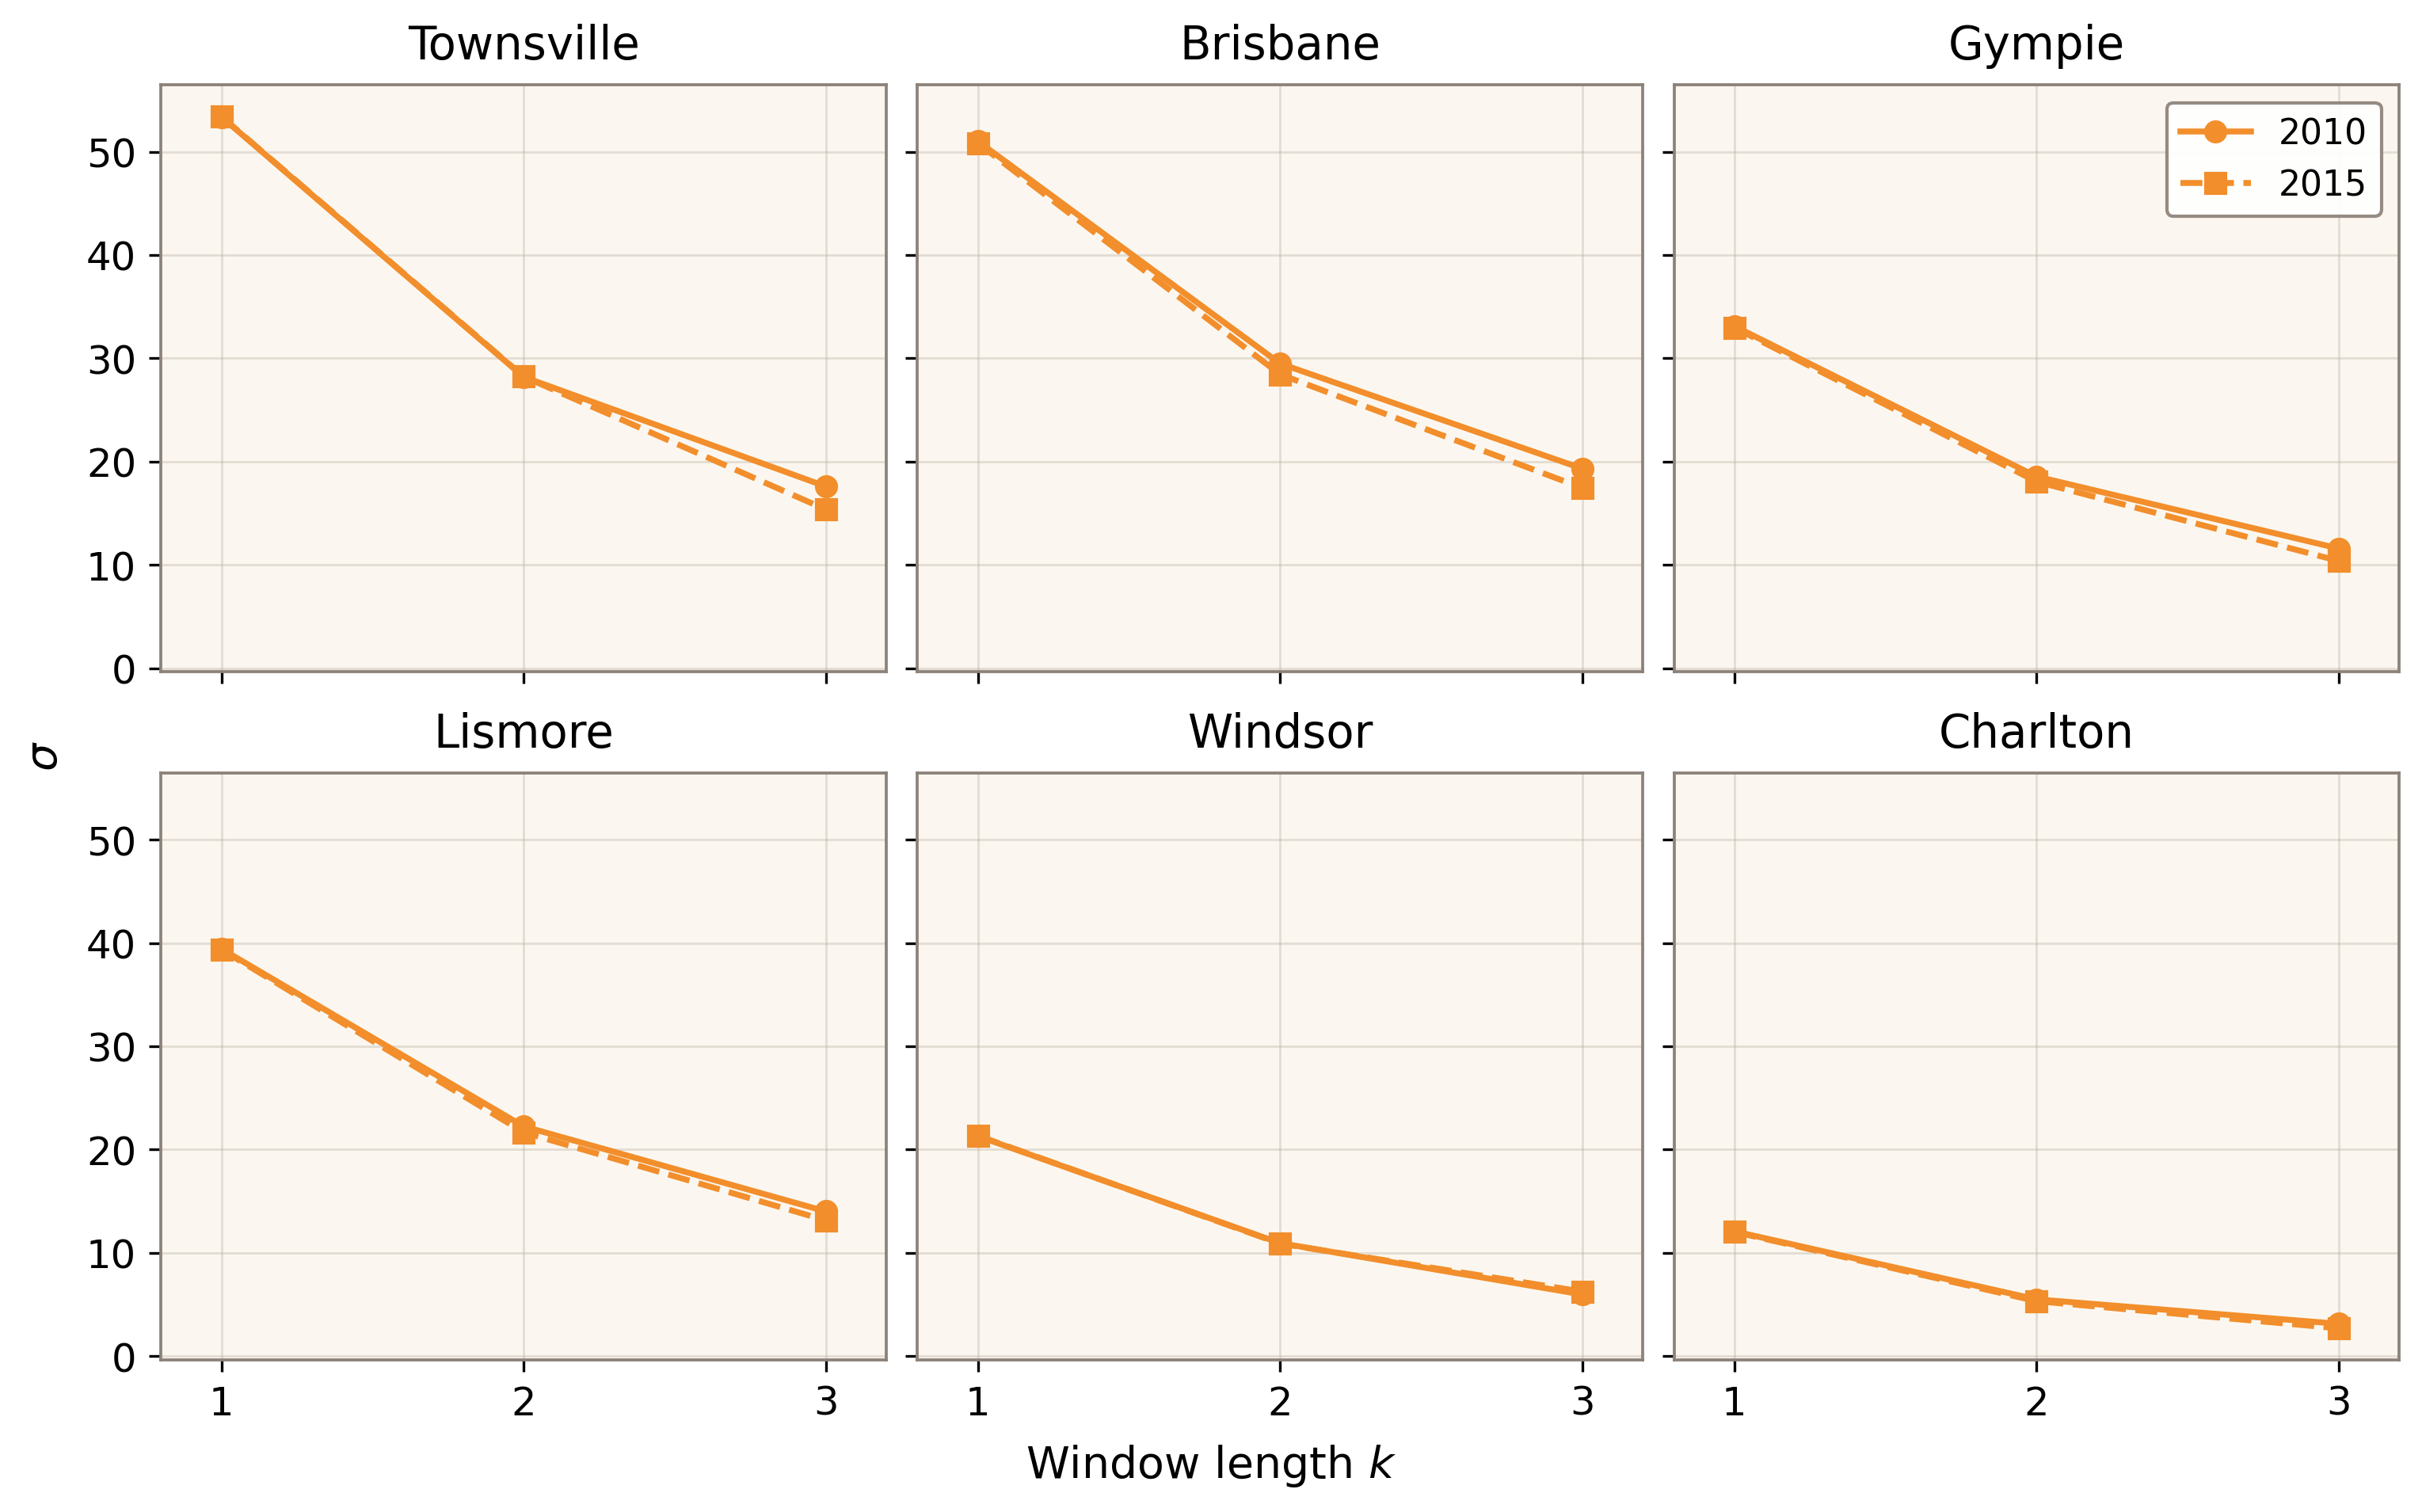

### Figure 3.10 — Fitted GEV densities, 2010

`model4_pdf_year_2010_2x3_shared_y.png`

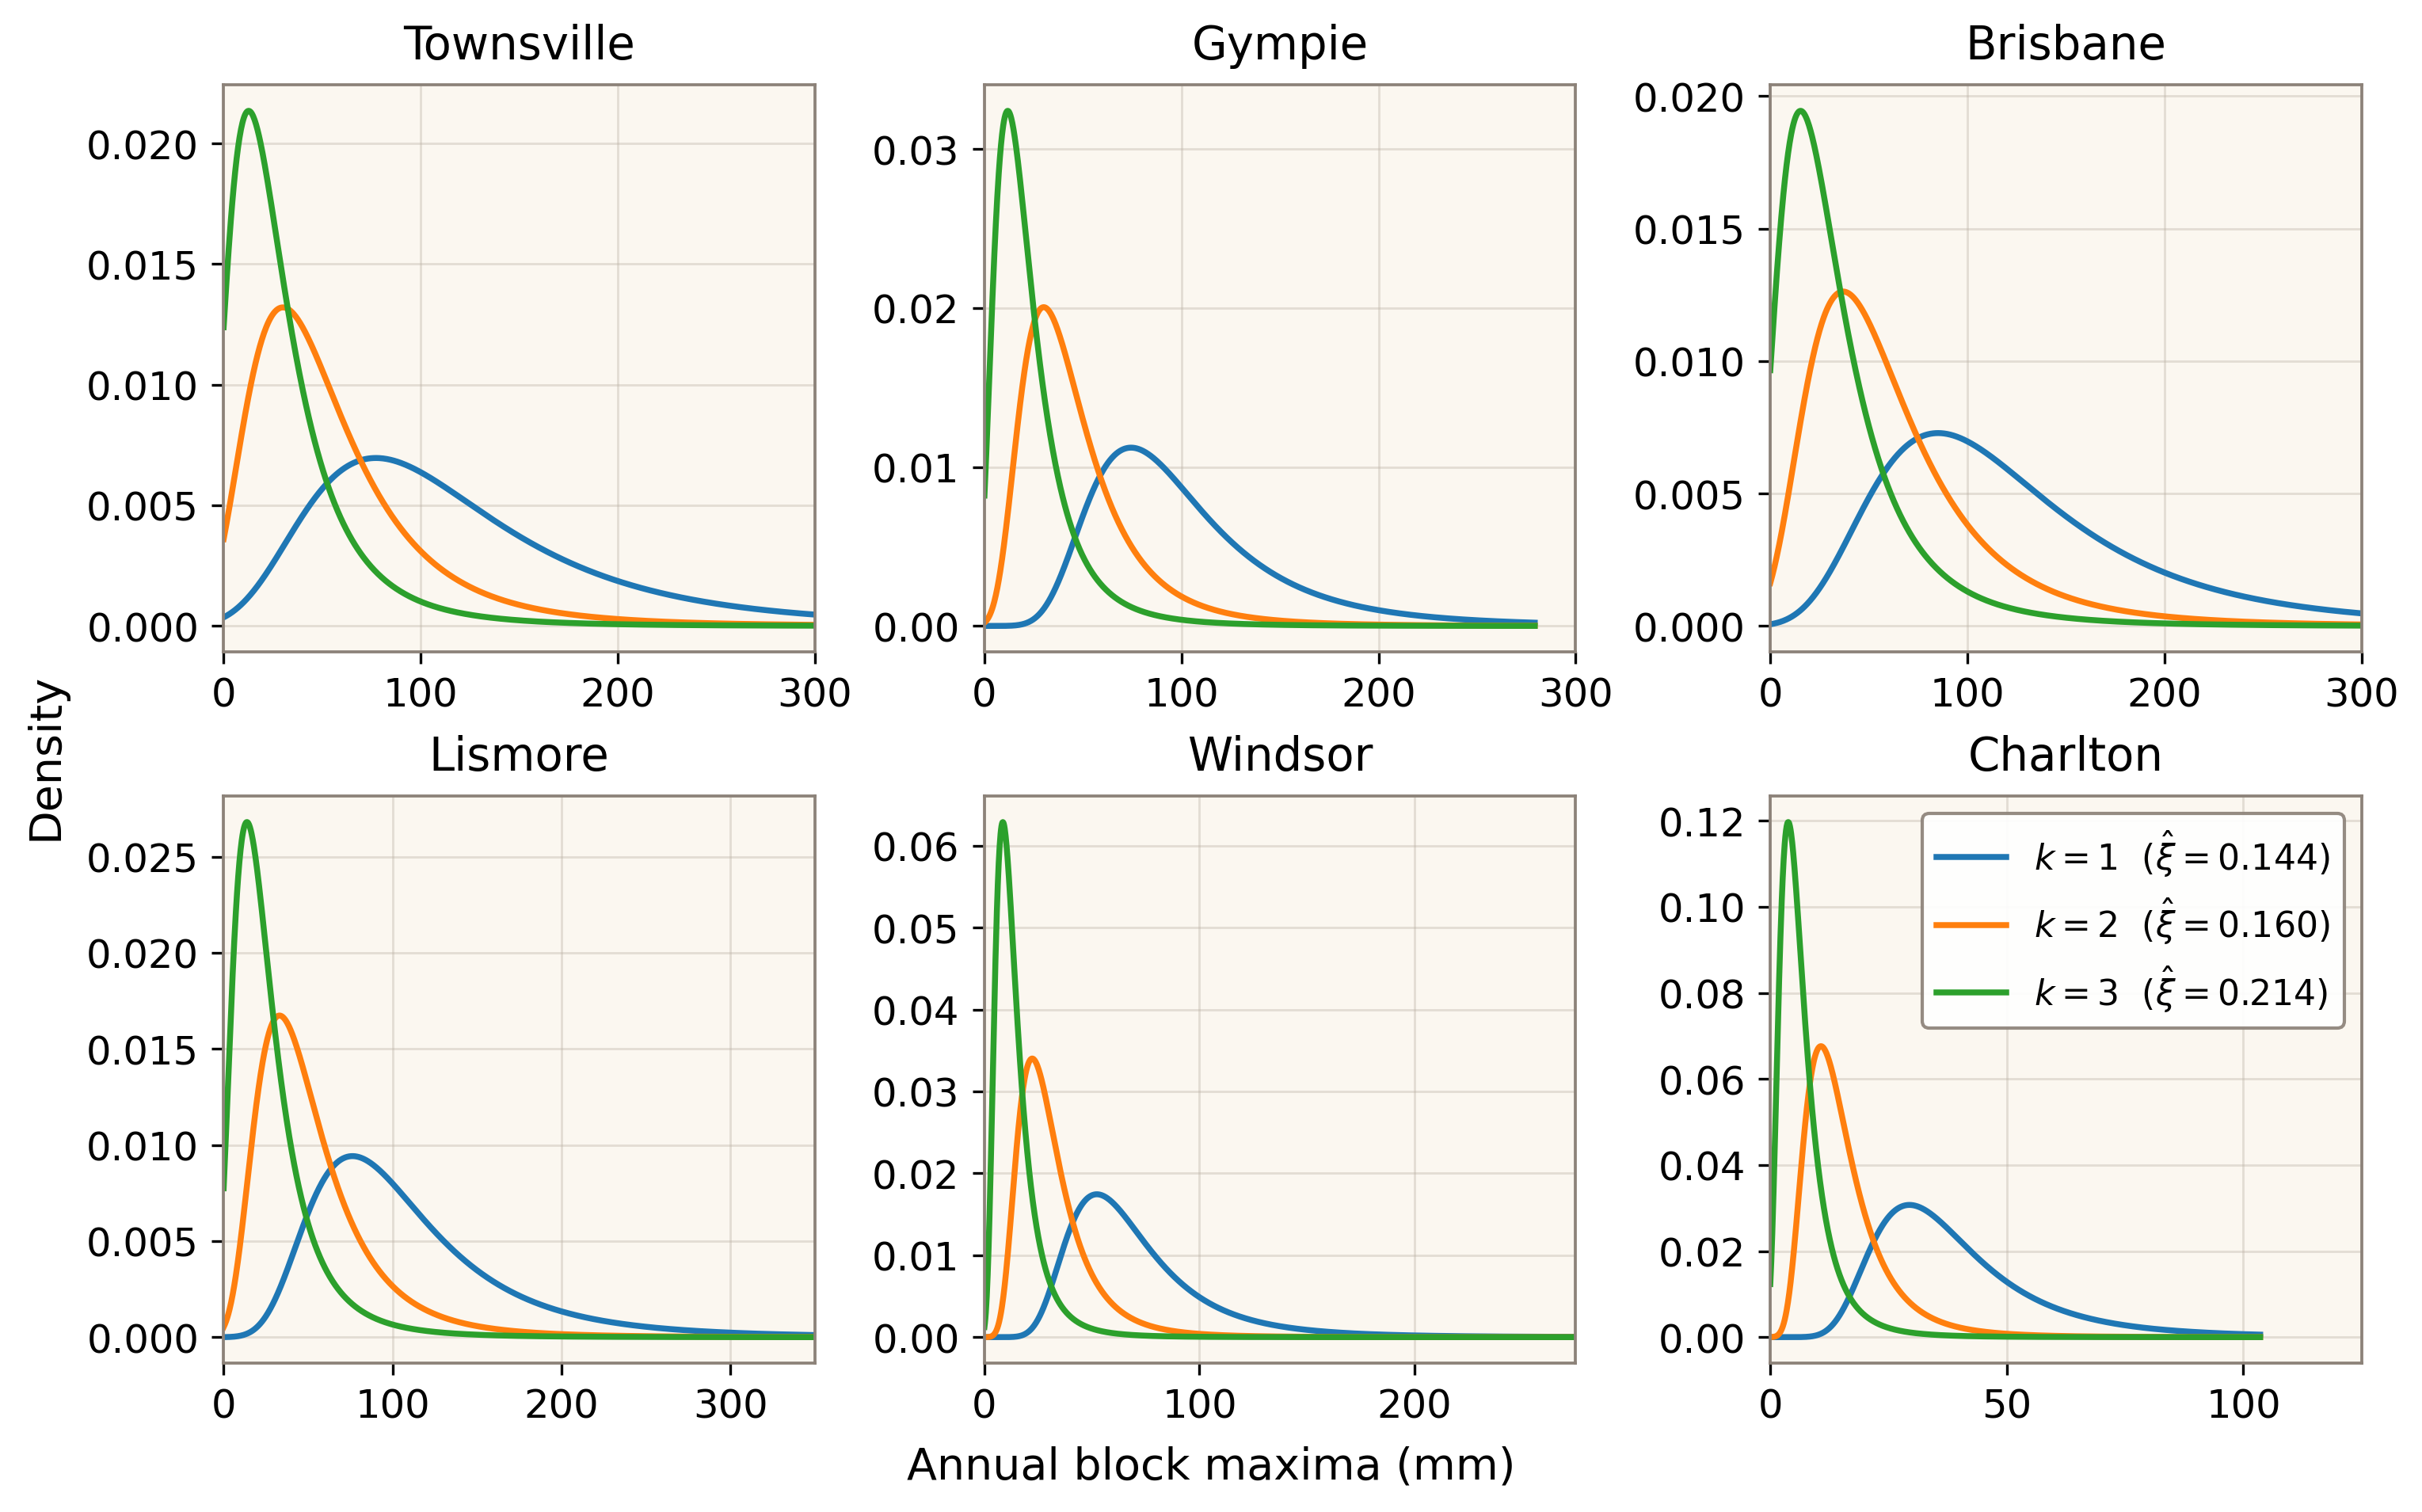

### Figure 3.11 — Return level curves, 2010

`model4_returnlevel_year_2010_2x3_shared_y.png`

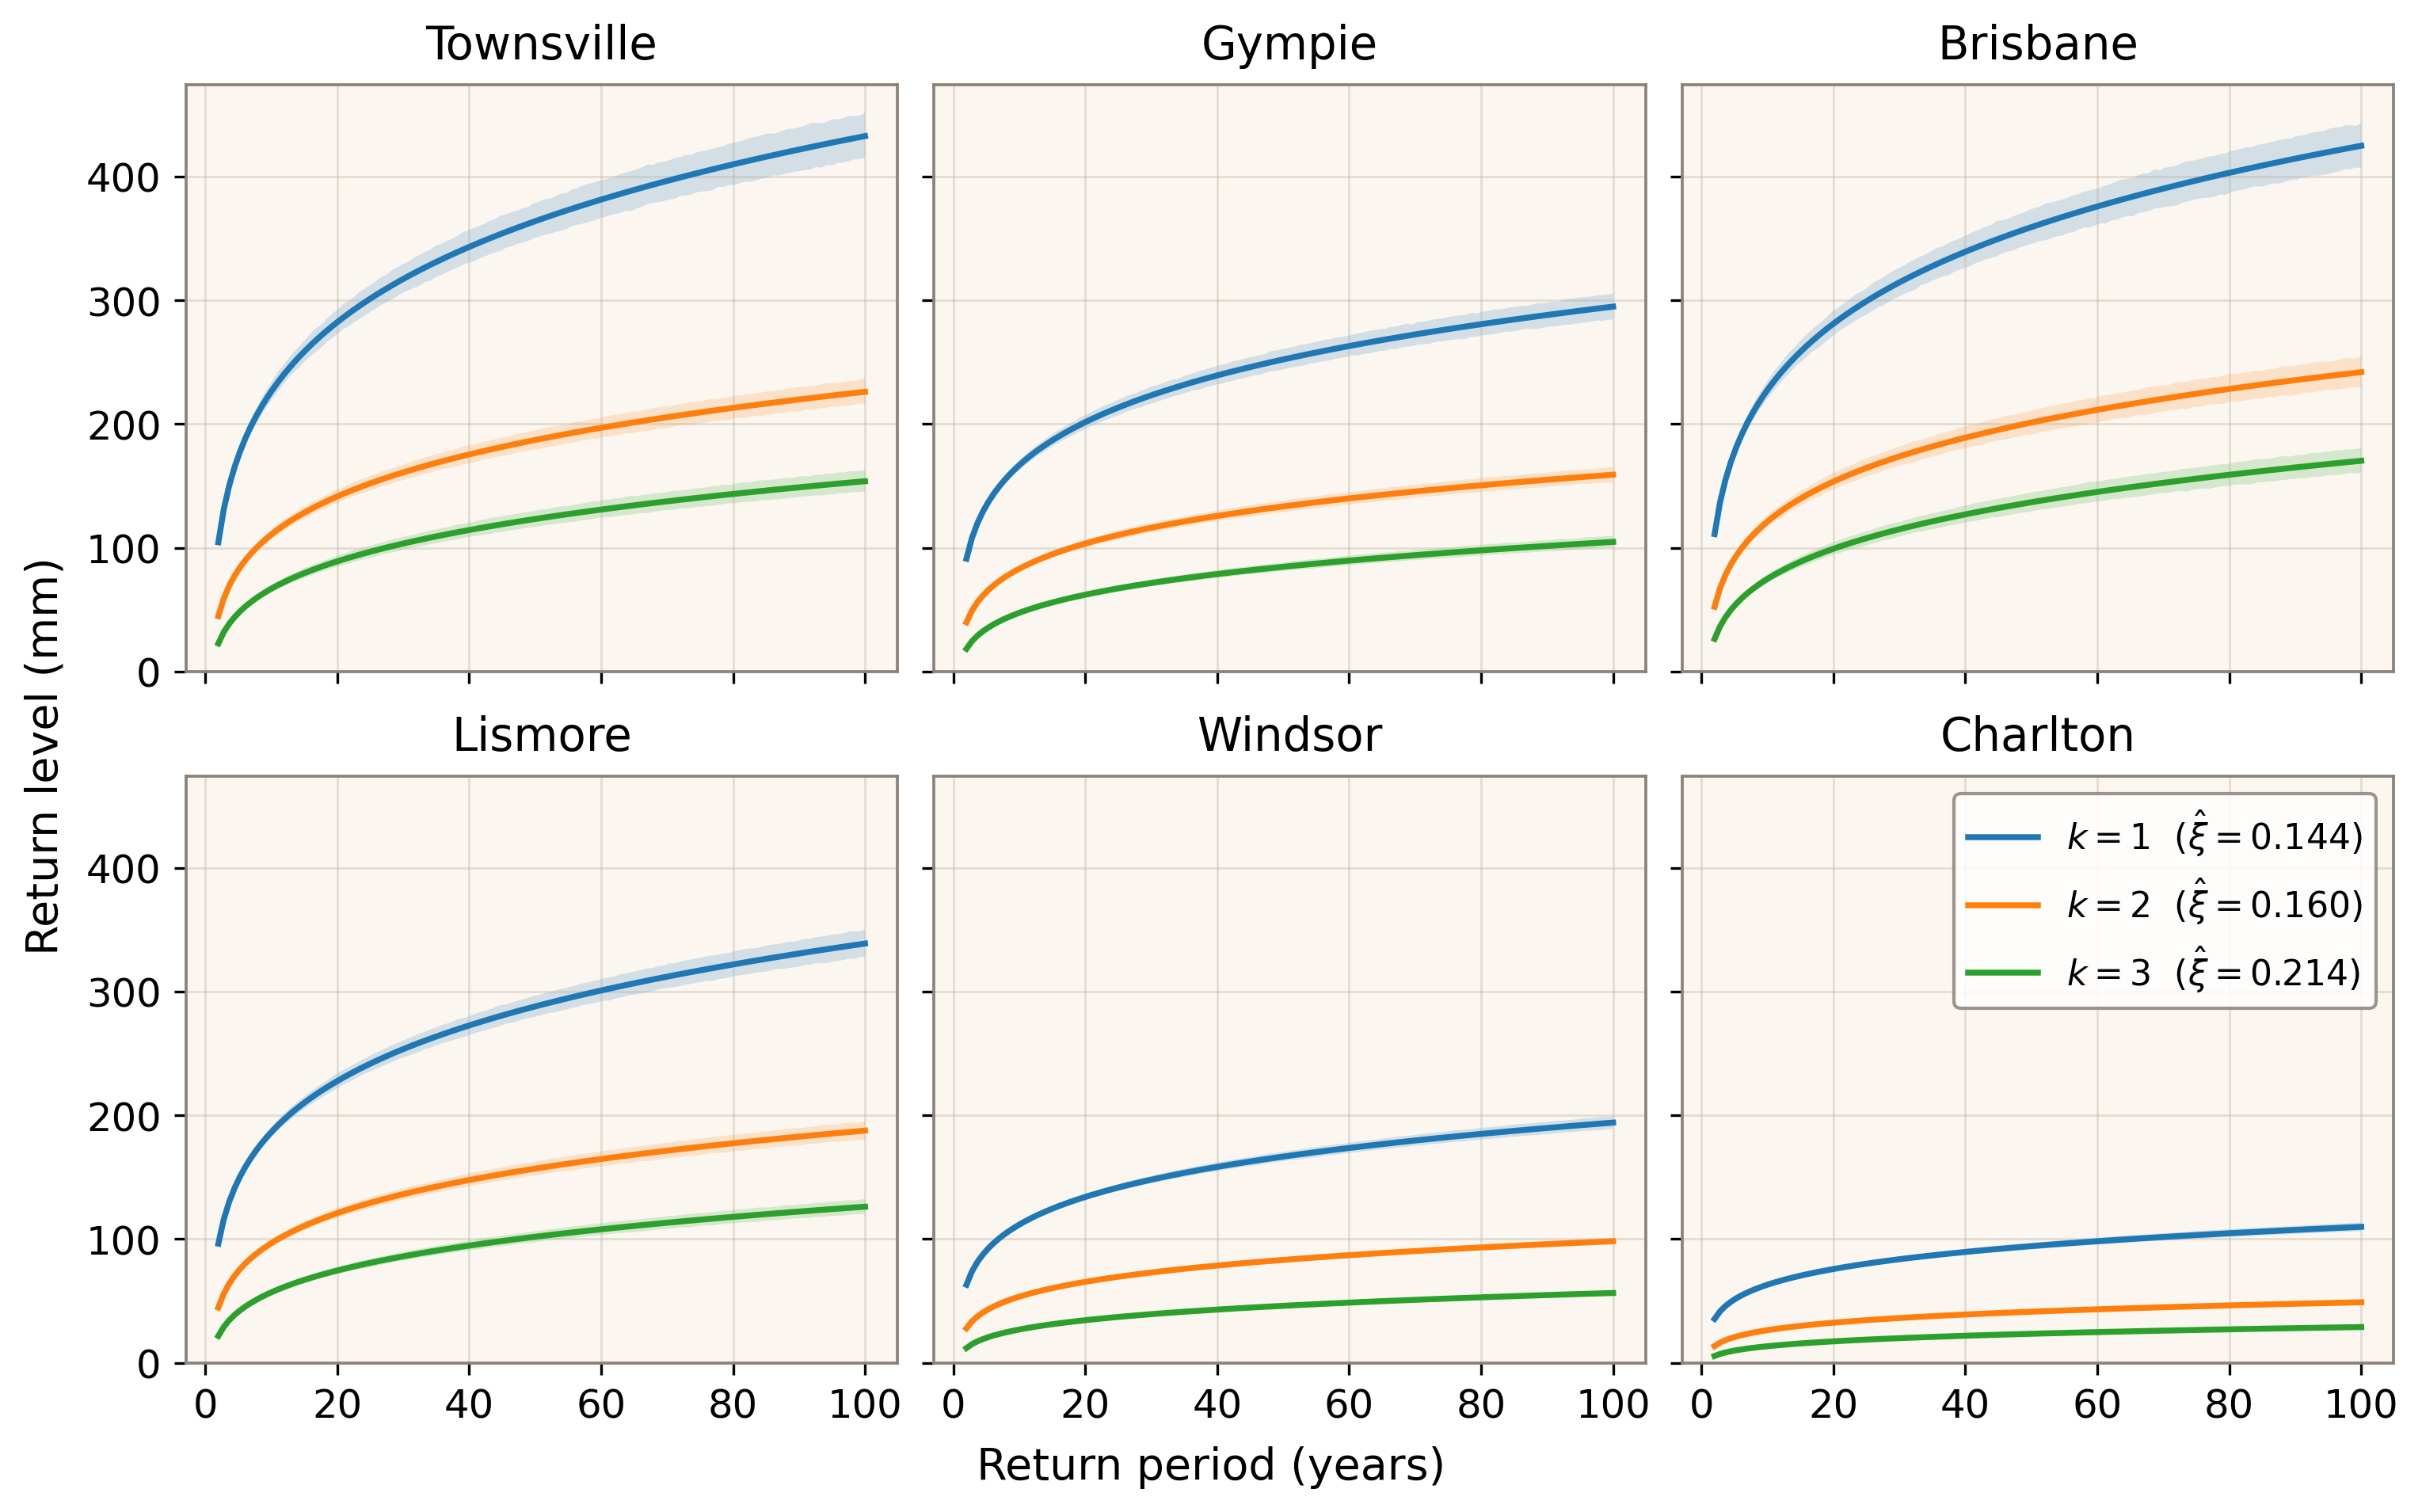

### Figure 3.12 — Return levels by station

`return_level_over_station_id_noCI.png`

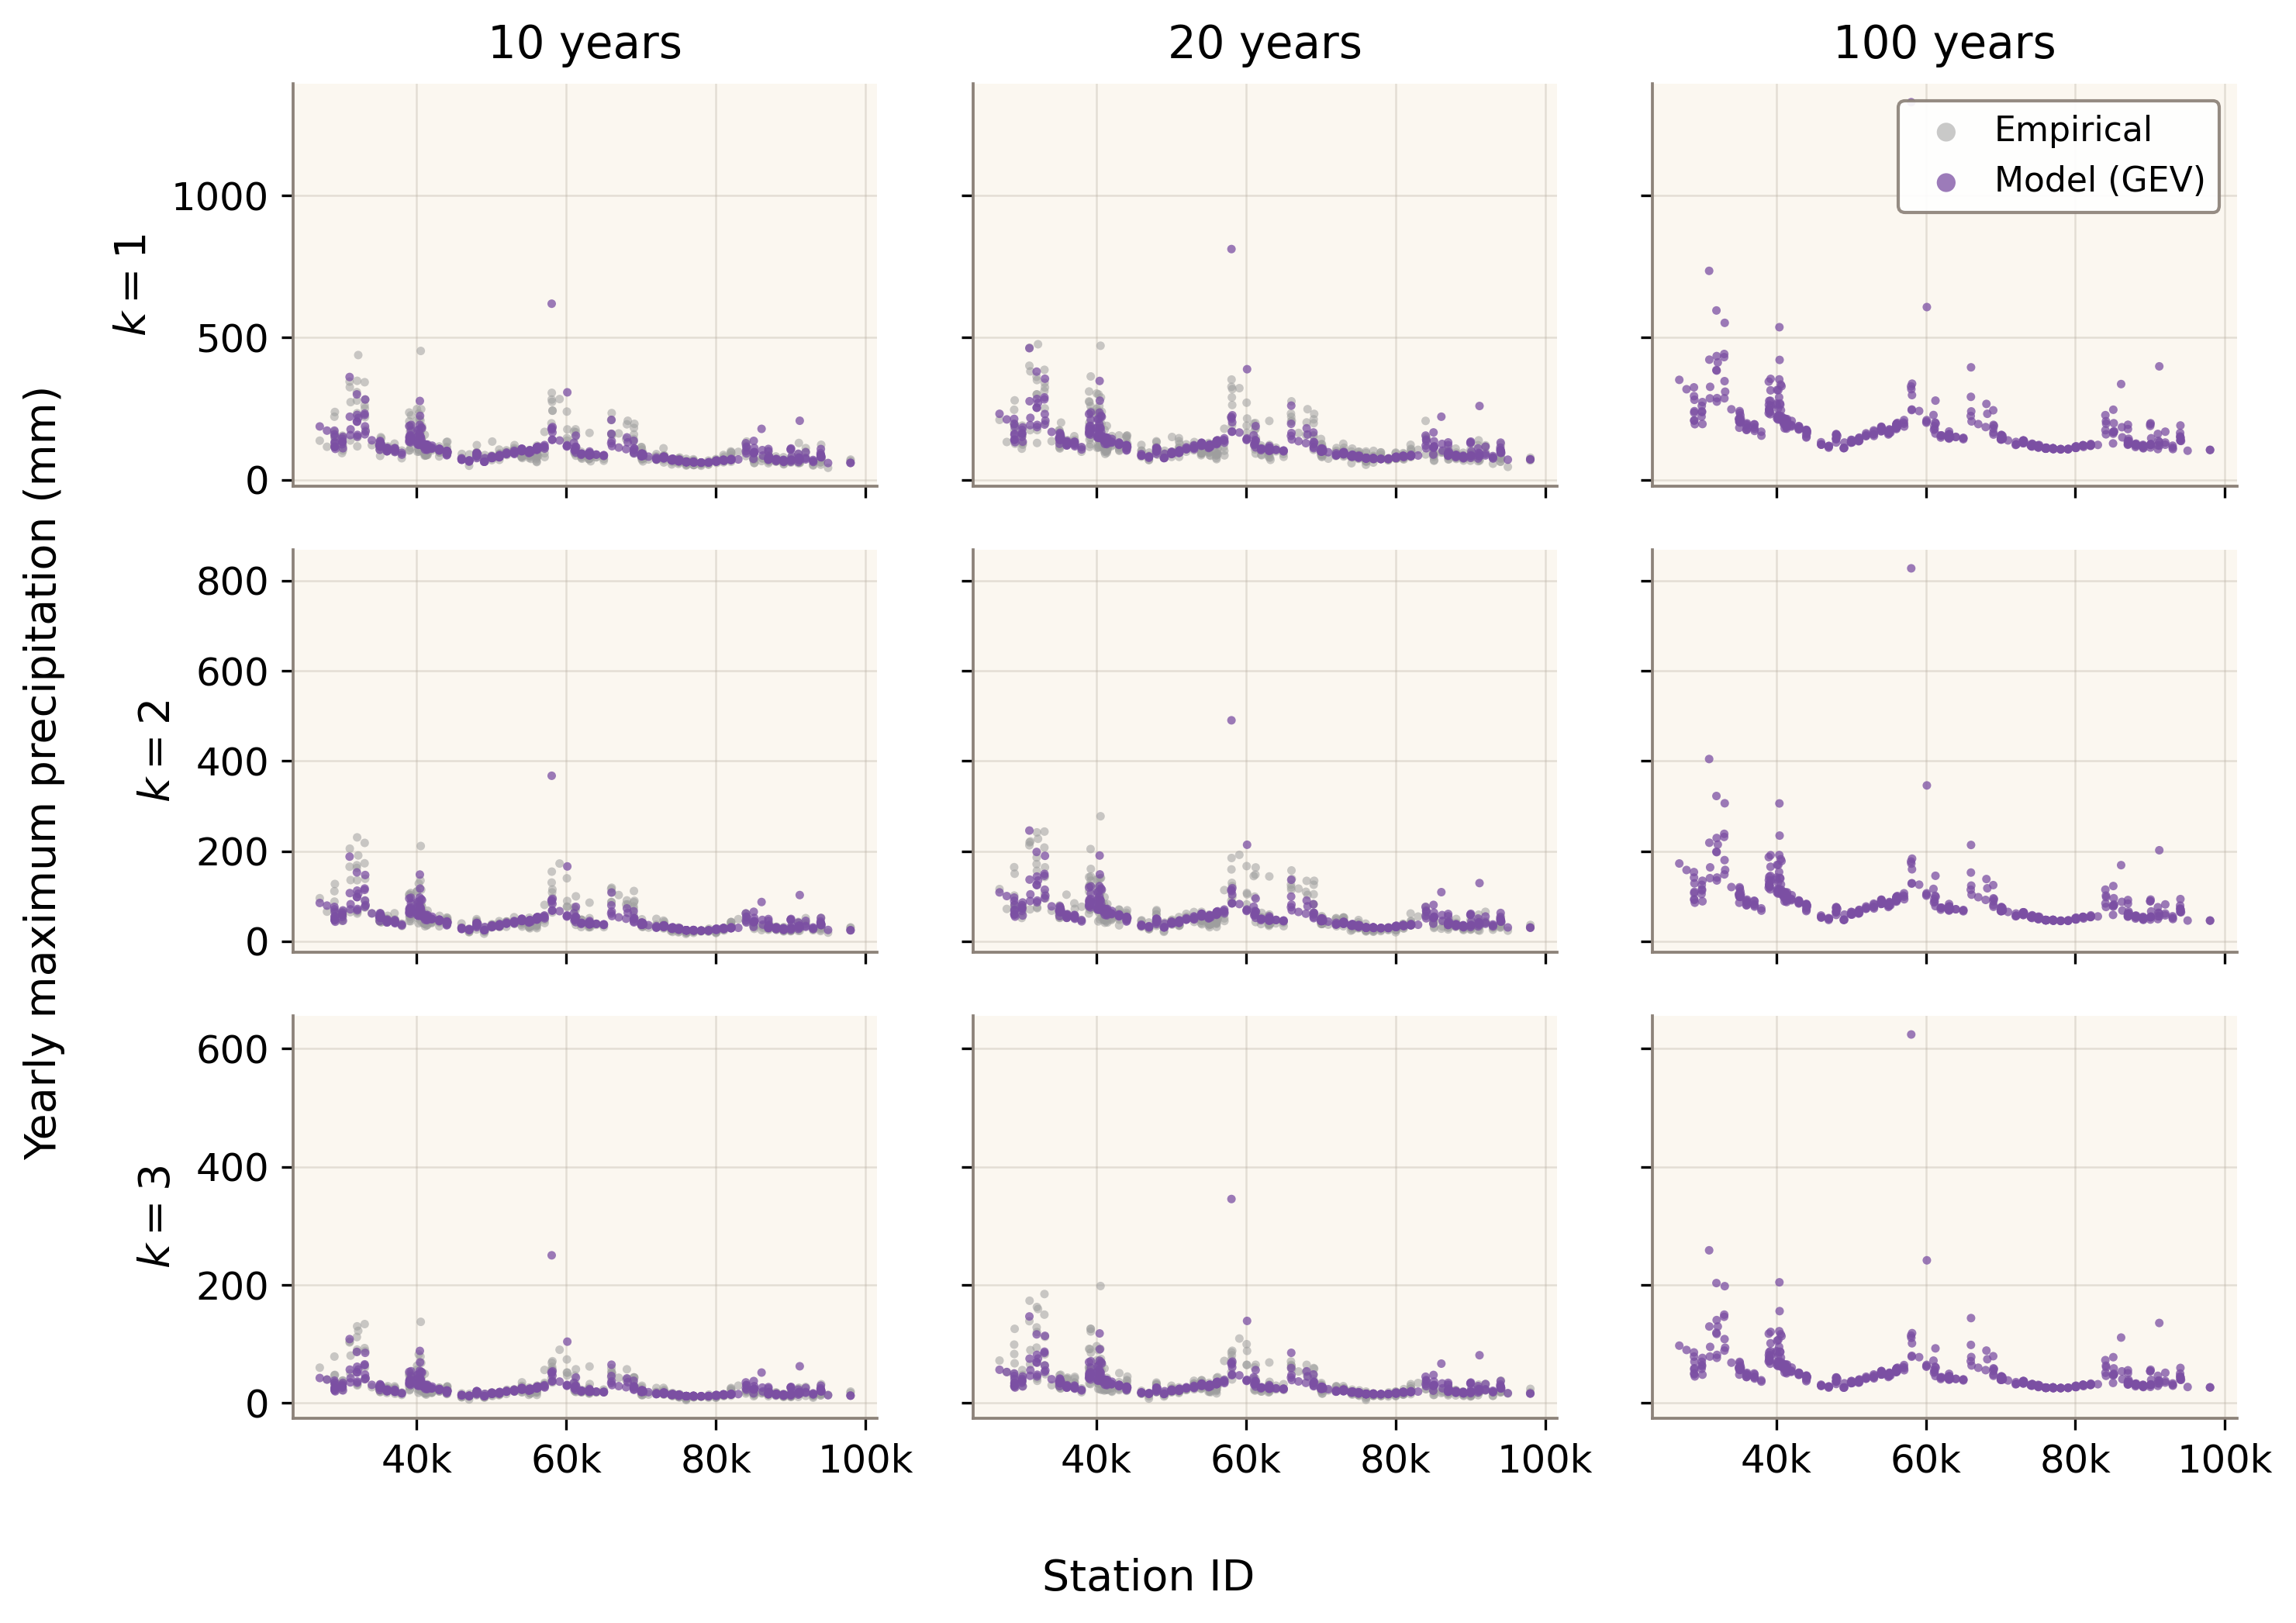

### Figure 3.13 — Spatial return levels

`maps.png`

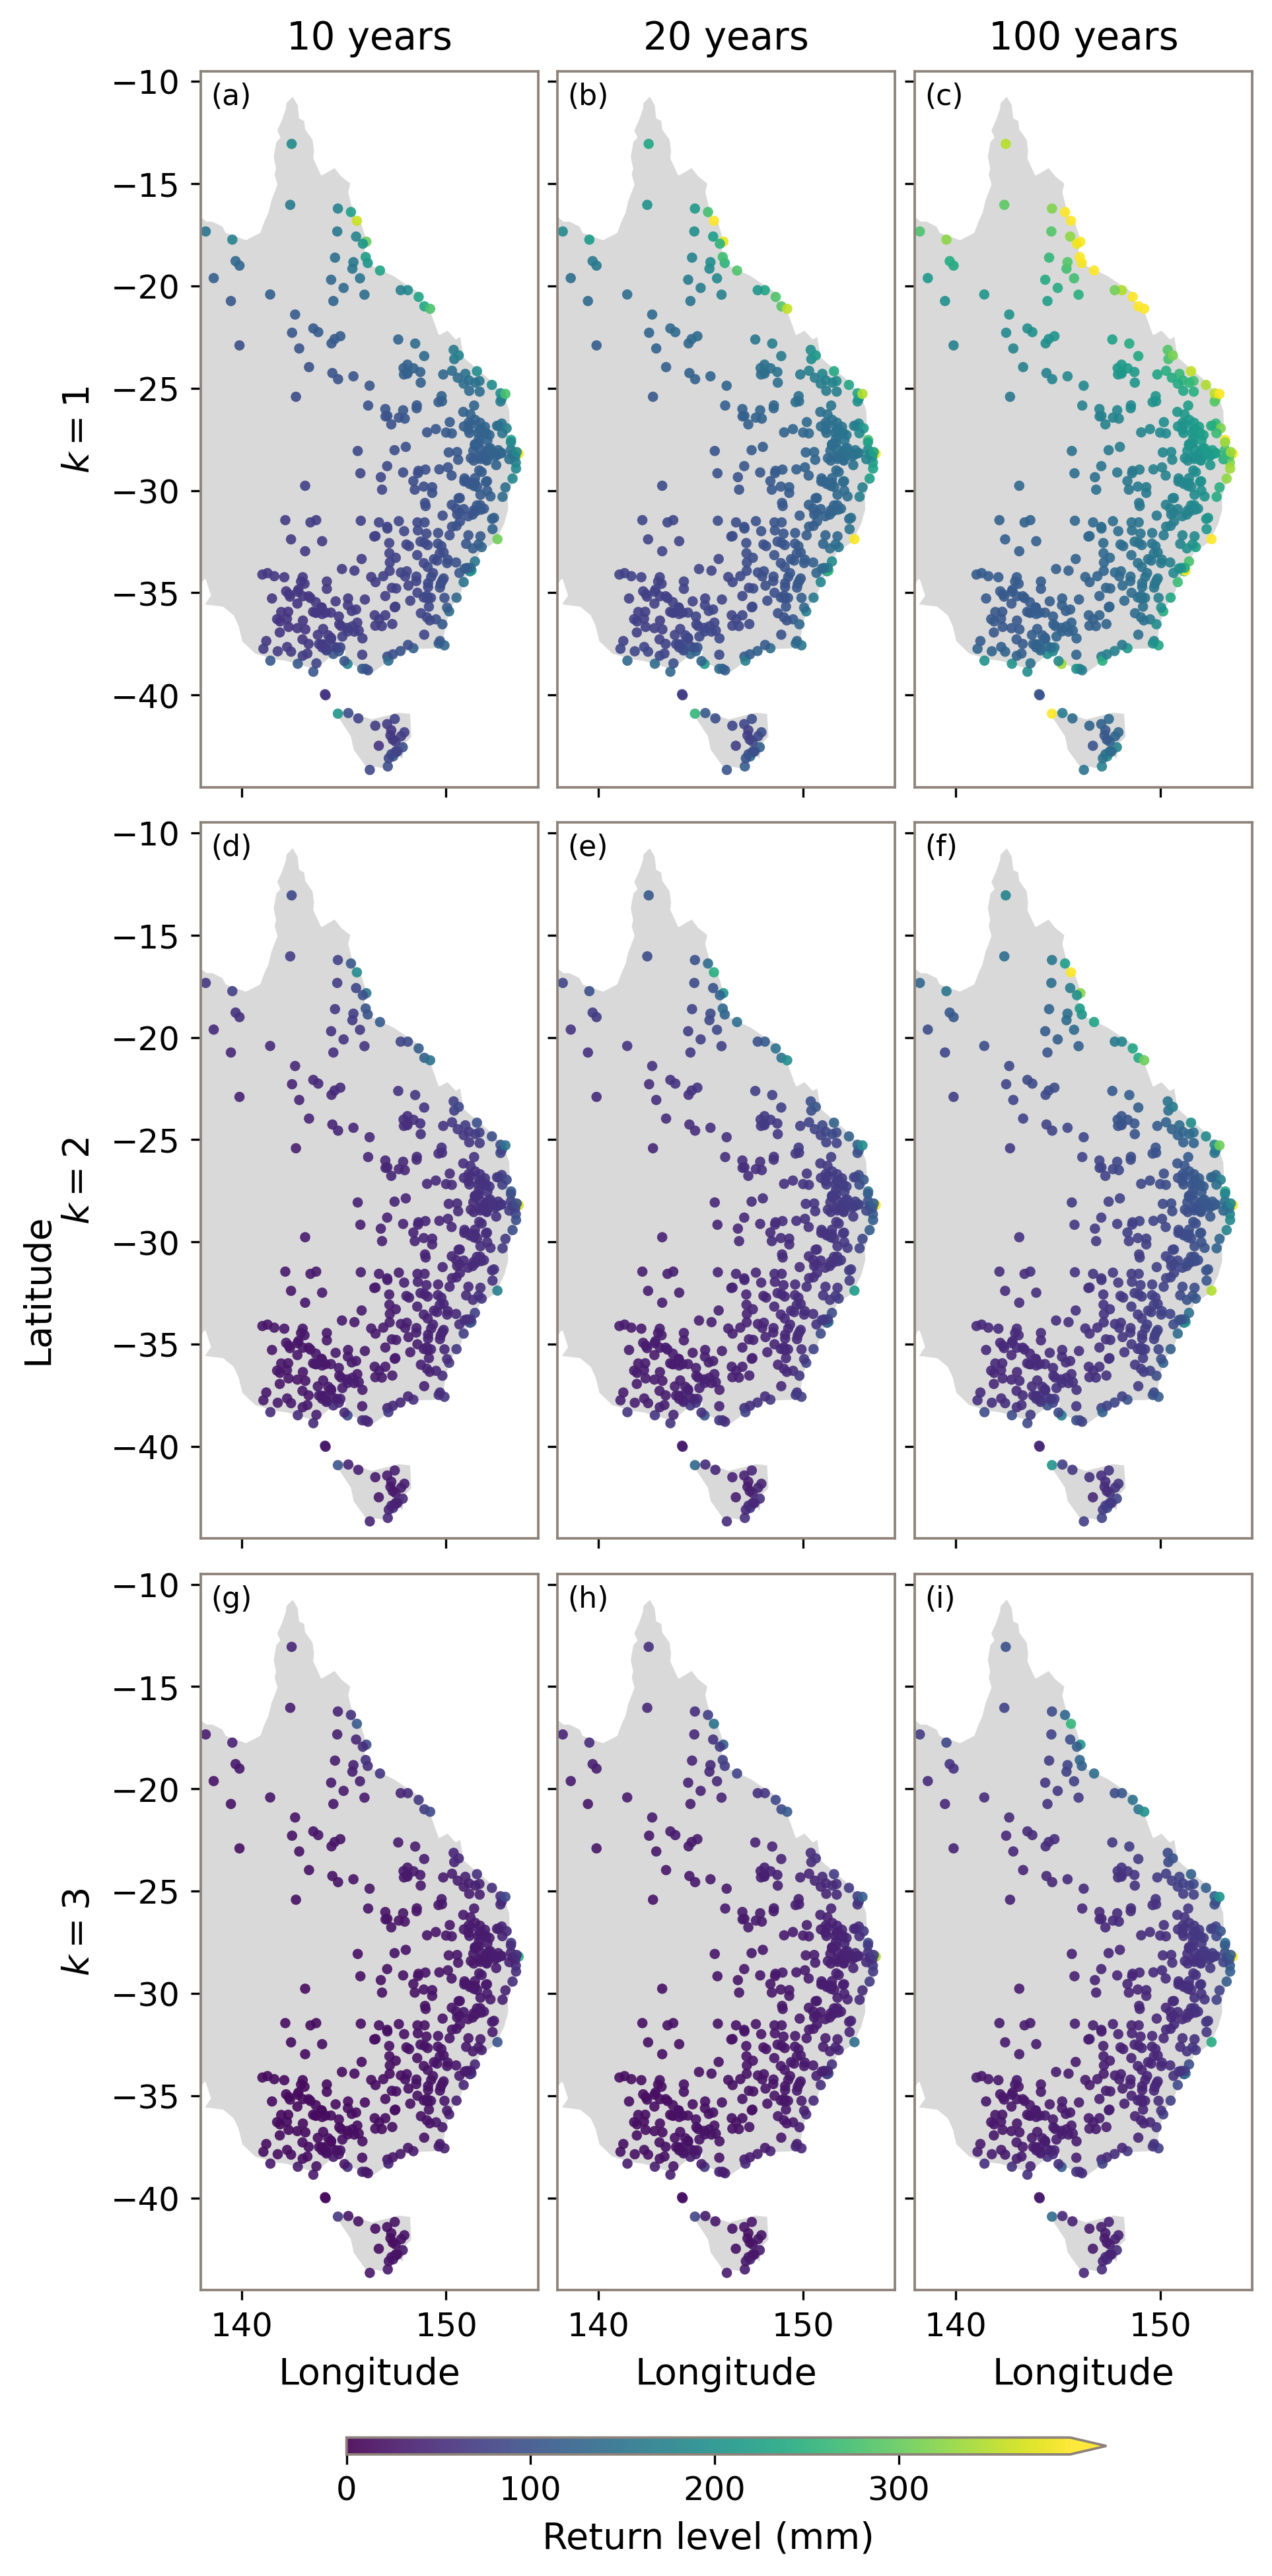

In [3]:
FIGURES = [
    ("3.1",  "annual_max_vs_covariates_combined_3x2.png", "Annual maxima against covariates"),
    ("3.2",  "0.95.PNG",                                   "Extremal index at u = 0.95"),
    ("3.3",  "shape_parameter_model4_over_k.png",          "Shape parameter over block length"),
    ("3.4",  "boxplot_mm_k.png",                           "Annual maxima for k = 1..10"),
    ("3.5",  "model4_mu_sigma_shape_over_k_3x3.png",       "GEV parameters over k"),
    ("3.6",  "selected_stations_map_fixed.png",            "Selected stations"),
    ("3.7",  "boxplot_k1234_shared_ylim.png",              "Annual moving minima, selected stations"),
    ("3.8",  "model4_mu_over_k_1_to_3_clean_same_ylim.png","Location parameter"),
    ("3.9",  "model4_sigma_over_k_1_to_3_clean_same_ylim.png","Scale parameter"),
    ("3.10", "model4_pdf_year_2010_2x3_shared_y.png",      "Fitted GEV densities, 2010"),
    ("3.11", "model4_returnlevel_year_2010_2x3_shared_y.png","Return level curves, 2010"),
    ("3.12", "return_level_over_station_id_noCI.png",      "Return levels by station"),
    ("3.13", "maps.png",                                    "Spatial return levels"),
]
def find(fname):
    """chapter3_figures holds maps.pdf (vector, for LaTeX); the PNG preview of
    the same figure is written to thesis_figures."""
    for folder in ("chapter3_figures", "thesis_figures"):
        p = OUT / folder / fname
        if p.exists():
            return p
    return None

for num, fname, caption in FIGURES:
    display(Markdown(f"### Figure {num} — {caption}\n\n`{fname}`"))
    p = find(fname)
    display(Image(str(p), width=760) if p else Markdown(f"*missing: {fname}*"))

### Figure 3.13

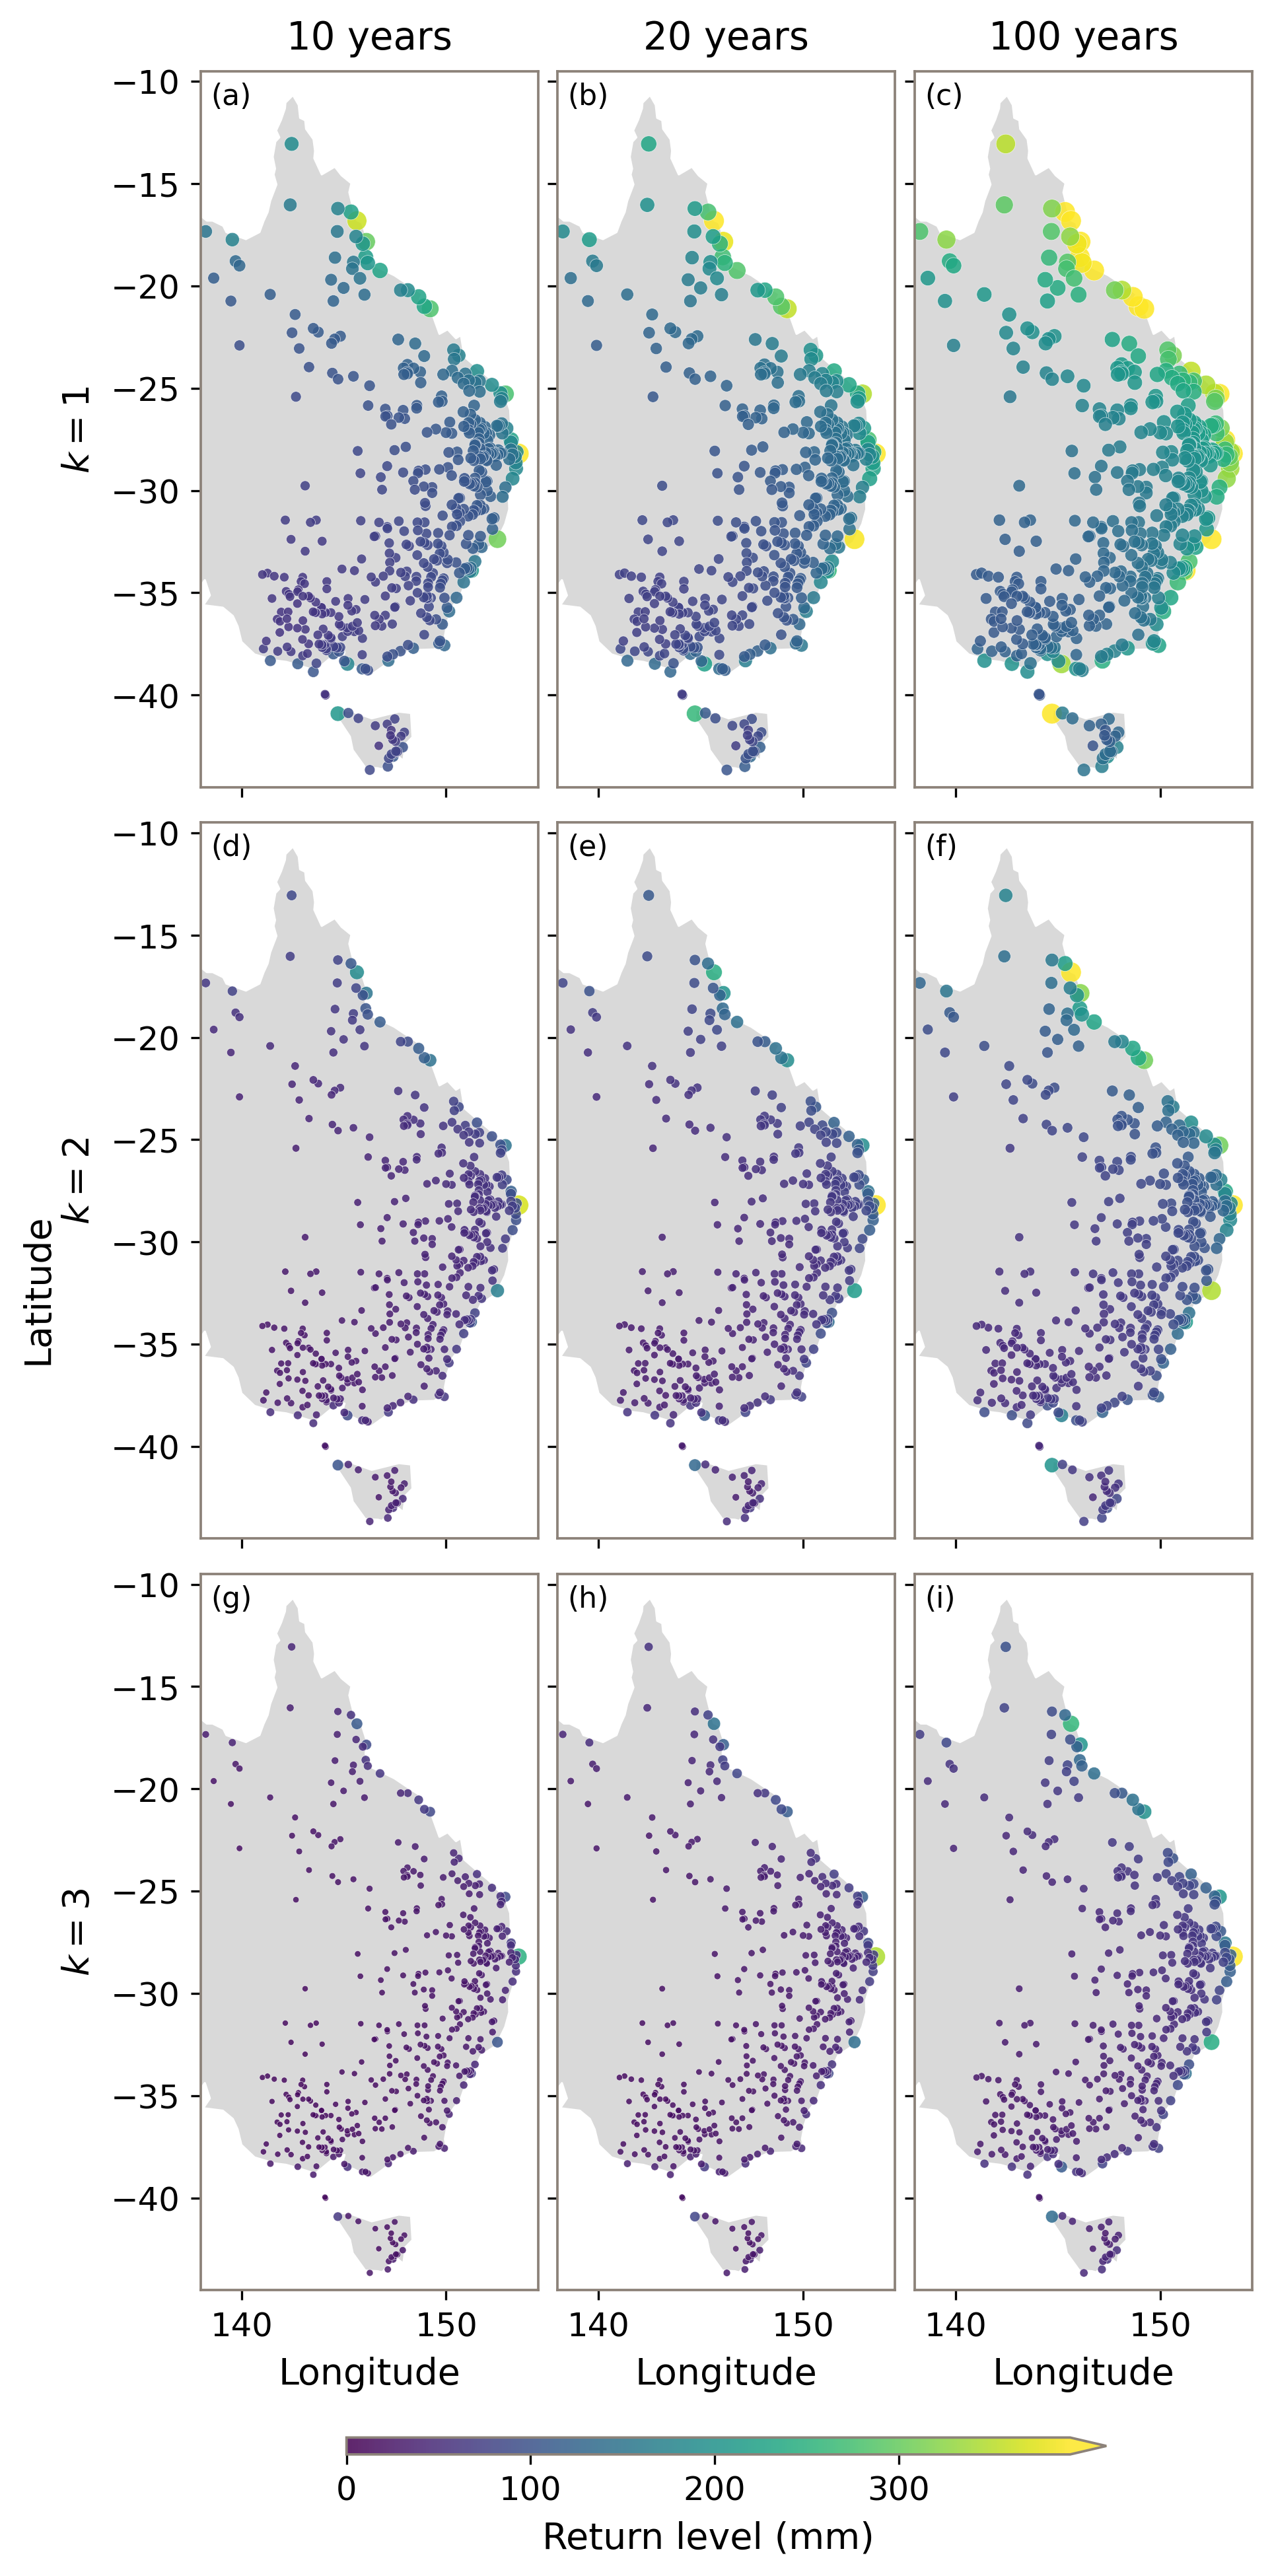

In [4]:
p = next((q for q in (OUT/"chapter3_figures"/"maps_graduated.png",
                      OUT/"thesis_figures"/"maps_graduated.png") if q.exists()), None)
display(Image(str(p), width=760) if p else Markdown("*not generated*"))